#Review & Evaluation of Data Quality
### Perbandingan: Raw → Cleaned → Cleaned2

**Dataset yang dibandingkan:**
| Dataset | Deskripsi |
|---|---|
| `shopping_behavior_raw.csv` | Data mentah sebelum cleaning |
| `shopping_behavior_cleaned.csv` | Data hasil cleaning (UTS) |
| `shopping_behavior_for_modeling.csv` | Data final dengan feature engineering |


## Import Library & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


raw_df   = pd.read_csv("shopping_behavior_raw.csv")
clean_df = pd.read_csv("shopping_behavior_cleaned.csv")
model_df = pd.read_csv("shopping_behavior_for_modeling.csv")

print(f"Raw Data      : {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
print(f"Cleaned Data  : {clean_df.shape[0]:,} rows × {clean_df.shape[1]} columns")
print(f"Final Data : {model_df.shape[0]:,} rows × {model_df.shape[1]} columns")


Raw Data      : 3,900 rows × 18 columns
Cleaned Data  : 3,900 rows × 17 columns
Final Data : 3,900 rows × 19 columns


In [ ]:
# Setting Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

COLOR_RAW   = "#E07B6A"
COLOR_CLEAN = "#6AAFE0"
COLOR_MODEL = "#6AE0A3"

## Ringkasan Masalah Kualitas Data (Mid Project)

Sebelum proses data wrangling, dataset shopping_behavior_raw.csv mengandung masalah kualitas data yang diidentifikasi selama project UTS. Berikut rangkumannya:



####Missing Values

In [ ]:
missing_raw = raw_df.isnull().sum()
total_cells = raw_df.shape[0] * raw_df.shape[1]
total_missing = missing_raw.sum()

print("MISSING VALUES — RAW DATA")
print(f"{'Kolom':<25} | {'Missing Count':<13} | {'Missing (%)'}")

for kolom, nilai in missing_raw.sort_values(ascending=False).items():
    persentase = round(nilai / len(raw_df) * 100, 2)
    print(f"{kolom:<25} | {nilai:<13,} | {persentase:.2f}%")


print(f"Total missing cells : {total_missing:,} / {total_cells:,} ")
print(f"({total_missing/total_cells*100:.2f}%)")

if total_missing == 0:
    print("Kesimpulan: Tidak ada missing value yang ditemukan di seluruh dataset")

MISSING VALUES — RAW DATA
Kolom                     | Missing Count | Missing (%)
Customer ID               | 0             | 0.00%
Age                       | 0             | 0.00%
Gender                    | 0             | 0.00%
Item Purchased            | 0             | 0.00%
Category                  | 0             | 0.00%
Purchase Amount (USD)     | 0             | 0.00%
Location                  | 0             | 0.00%
Size                      | 0             | 0.00%
Color                     | 0             | 0.00%
Season                    | 0             | 0.00%
Review Rating             | 0             | 0.00%
Subscription Status       | 0             | 0.00%
Shipping Type             | 0             | 0.00%
Discount Applied          | 0             | 0.00%
Promo Code Used           | 0             | 0.00%
Previous Purchases        | 0             | 0.00%
Payment Method            | 0             | 0.00%
Frequency of Purchases    | 0             | 0.00%
Total missing cell

####Duplicate Rows

In [ ]:
dup_raw = raw_df.duplicated().sum()
print("DUPLICATE ROWS — RAW DATA")
print(f"Duplicate rows : {dup_raw:} ({dup_raw/len(raw_df)*100:.2f}%)")
if dup_raw== 0:
    print("Kesimpulan : Tidak ada duplikasi data")


DUPLICATE ROWS — RAW DATA
Duplicate rows : 0 (0.00%)
Kesimpulan : Tidak ada duplikasi data


####Cek Outlier

In [ ]:

numeric_cols = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]

def count_outliers_iqr(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

print('OUTLIERS — RAW DATA (IQR Method)')
total_raw_outliers = 0
for col in numeric_cols:
    if col in raw_df.columns:
        count = count_outliers_iqr(raw_df, col)
        print(f"  {col:<22}: {int(count):>5} outliers")
        total_raw_outliers = total_raw_outliers + count

print(f"\nTotal Outliers di Raw Data: {int(total_raw_outliers)}")

OUTLIERS — RAW DATA (IQR Method)
  Age                   :     0 outliers
  Purchase Amount (USD) :     0 outliers
  Review Rating         :     0 outliers
  Previous Purchases    :     0 outliers

Total Outliers di Raw Data: 0


####Invalid Values

In [ ]:
checks = {
    "Age ≤ 15 or > 100":raw_df[(raw_df["Age"]<=15) | (raw_df["Age"]>100)],
    "Purchase Amount < 0":raw_df[raw_df["Purchase Amount (USD)"]<0],
    "Review Rating < 0 or > 5":raw_df[(raw_df["Review Rating"]<0)|(raw_df["Review Rating"]>5)],
}

print("INVALID VALUES — RAW DATA")
invalid = False
for desc, subset in checks.items():
    if len(subset) > 0:
        invalid = True
        print(f"{desc}: {len(subset):} rows")
if not invalid:
    print("Tidak ada nilai di luar rentang valid")


INVALID VALUES — RAW DATA
Tidak ada nilai di luar rentang valid


####Category Inkonsistensi

In [ ]:
cat_cols = ["Gender", "Season", "Subscription Status", "Shipping Type", "Payment Method", "Frequency of Purchases"]

print("CATEGORY CONSISTENCY — RAW DATA\n")
for col in cat_cols:
    if col in raw_df.columns:
        jumlah_asli = raw_df[col].nunique()
        jumlah_bersih = raw_df[col].astype(str).str.strip().str.lower().nunique()
        isi_kategori = sorted(raw_df[col].astype(str).unique())
        if jumlah_bersih < jumlah_asli:
            print(f"'{col}' — Kemungkinan spasi/kapitalisasi tidak konsisten")
        else:
            print(f"'{col}' — {jumlah_asli} kategori unik:")

        print(f"Kategori: {isi_kategori}\n")

print("Ditemukan inkonsistensi pada fitur Frequency of Purchases dimana Bi-Weekly dan Fortnightly memiliki makna sama serta Every 3 Months maknanya sama dengan Quarterly")

CATEGORY CONSISTENCY — RAW DATA

'Gender' — 2 kategori unik:
Kategori: ['Female', 'Male']

'Season' — 4 kategori unik:
Kategori: ['Fall', 'Spring', 'Summer', 'Winter']

'Subscription Status' — 2 kategori unik:
Kategori: ['No', 'Yes']

'Shipping Type' — 6 kategori unik:
Kategori: ['2-Day Shipping', 'Express', 'Free Shipping', 'Next Day Air', 'Standard', 'Store Pickup']

'Payment Method' — 6 kategori unik:
Kategori: ['Bank Transfer', 'Cash', 'Credit Card', 'Debit Card', 'PayPal', 'Venmo']

'Frequency of Purchases' — 7 kategori unik:
Kategori: ['Annually', 'Bi-Weekly', 'Every 3 Months', 'Fortnightly', 'Monthly', 'Quarterly', 'Weekly']

Ditemukan inkonsistensi pada fitur Frequency of Purchases dimana Bi-Weekly dan Fortnightly memiliki makna sama serta Every 3 Months maknanya sama dengan Quarterly


###Cek Data Type

In [ ]:
print("DATA TYPES — RAW DATA")
print(raw_df.dtypes.to_string())

DATA TYPES — RAW DATA
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object


Summary Dataset Raw

In [ ]:
total_missing  = 0
total_dup      = 0
total_invalid  = 0
inconsist_cols = 1
outlier_cols = 0

summary_a = pd.DataFrame({
    "Kategori Masalah": [
        "Missing Values",
        "Duplicate Rows",
        "Invalid / Out-of-Range Values",
        "Category Inconsistency (kolom)",
        "Data Outlier"
    ],
    "Jumlah": [total_missing, total_dup, total_invalid, inconsist_cols,outlier_cols],
    "Status": [
        "Perlu ditangani" if total_missing > 0 else "Bersih",
        "Perlu ditangani" if total_dup > 0      else "Bersih",
        "Perlu ditangani" if total_invalid > 0  else "Bersih",
        "Perlu ditangani" if inconsist_cols > 0 else "Bersih",
        "Perlu ditangani" if outlier_cols > 0 else "Bersih"
    ],
})
print("RINGKASAN MASALAH KUALITAS DATA RAW")
print(summary_a.to_string(index=False))


RINGKASAN MASALAH KUALITAS DATA RAW
              Kategori Masalah  Jumlah          Status
                Missing Values       0          Bersih
                Duplicate Rows       0          Bersih
 Invalid / Out-of-Range Values       0          Bersih
Category Inconsistency (kolom)       1 Perlu ditangani
                  Data Outlier       0          Bersih



## Evaluasi Efektivitas Data Wrangling



###Perbandingan Dimensi Dataset

      Dataset  Rows  Columns
          Raw  3900       18
Cleaned (UTS)  3900       17
     Cleaned2  3900       19


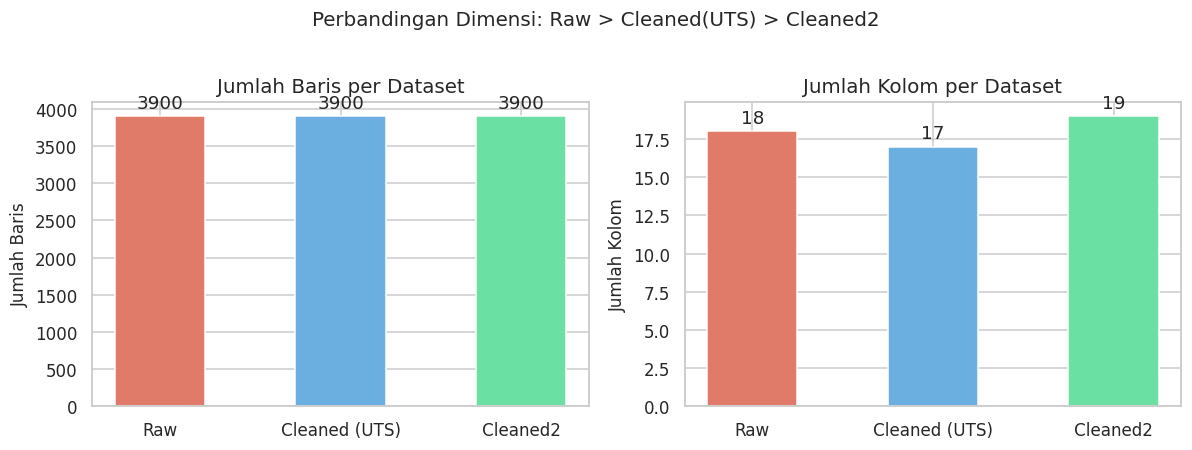

In [ ]:
dfs = {"Raw": raw_df, "Cleaned (UTS)": clean_df, "Cleaned2": model_df}
dim_compare = pd.DataFrame(
    [{"Dataset": name, "Rows": df.shape[0], "Columns": df.shape[1]} for name, df in dfs.items()]
)
print(dim_compare.to_string(index=False))


colors = [COLOR_RAW, COLOR_CLEAN, COLOR_MODEL]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

bars0 = axes[0].bar(dim_compare["Dataset"], dim_compare["Rows"], color=colors, width=0.5)
axes[0].set(title="Jumlah Baris per Dataset", ylabel="Jumlah Baris")
axes[0].bar_label(bars0, padding=3)


bars1 = axes[1].bar(dim_compare["Dataset"], dim_compare["Columns"], color=colors, width=0.5)
axes[1].set(title="Jumlah Kolom per Dataset", ylabel="Jumlah Kolom")
axes[1].bar_label(bars1, padding=3)

plt.suptitle("Perbandingan Dimensi: Raw > Cleaned(UTS) > Cleaned2", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

###Perbandingan Missing Values (3 Dataset)

  Missing Raw          : 0
  Missing Cleaned (UTS): 0  (reduksi 0.0% dari raw)
  Missing Cleaned2     : 0  (reduksi 0.0% dari raw)


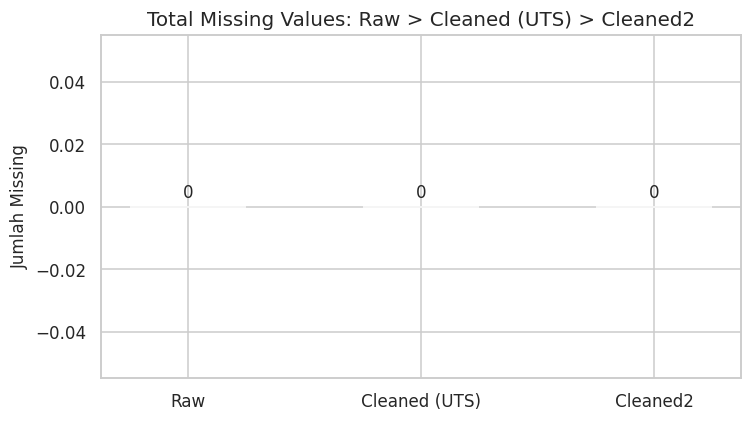

In [ ]:
mv_raw = raw_df.isnull().sum().sum()
mv_clean = clean_df.isnull().sum().sum()
mv_model = model_df.isnull().sum().sum()

reduksi_clean = ((mv_raw - mv_clean) / mv_raw * 100) if mv_raw > 0 else 0
reduksi_model = ((mv_raw - mv_model) / mv_raw * 100) if mv_raw > 0 else 0

print(f"  Missing Raw          : {mv_raw:,}")
print(f"  Missing Cleaned (UTS): {mv_clean:,}  (reduksi {reduksi_clean:.1f}% dari raw)")
print(f"  Missing Cleaned2     : {mv_model:,}  (reduksi {reduksi_model:.1f}% dari raw)")

nama_dataset = ["Raw", "Cleaned (UTS)", "Cleaned2"]
jumlah_missing = [mv_raw, mv_clean, mv_model]
warna_grafik = [COLOR_RAW, COLOR_CLEAN, COLOR_MODEL]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(nama_dataset, jumlah_missing, color=warna_grafik, width=0.5)

ax.bar_label(bars, padding=3, fontsize=11)

ax.set_title("Total Missing Values: Raw > Cleaned (UTS) > Cleaned2")
ax.set_ylabel("Jumlah Missing")

plt.tight_layout()
plt.show()

###Perbandingan Duplikasi Data

      Dataset  Duplicate Rows  Duplicate (%)
          Raw               0            0.0
Cleaned (UTS)               0            0.0
     Cleaned2               0            0.0


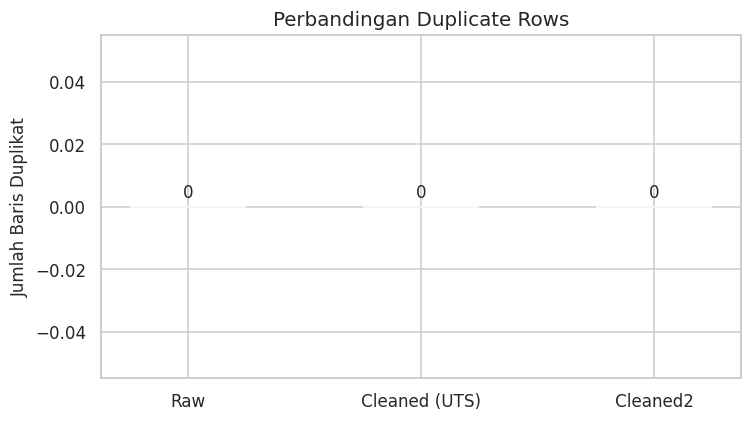

In [ ]:
dup_df = pd.DataFrame(
    [
        {
            "Dataset": name,
            "Duplicate Rows": df.duplicated().sum(),
            "Duplicate (%)": round(df.duplicated().sum() / len(df) * 100, 2),
        }
        for name, df in dfs.items()
    ]
)
print(dup_df.to_string(index=False))


fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    dup_df["Dataset"],
    dup_df["Duplicate Rows"],
    color=[COLOR_RAW, COLOR_CLEAN, COLOR_MODEL],
    width=0.5,
)

ax.bar_label(bars, padding=3, fontsize=11)

ax.set(title="Perbandingan Duplicate Rows", ylabel="Jumlah Baris Duplikat")

plt.tight_layout()
plt.show()

###Konsistensi Tipe Data

In [ ]:
dtype_df = pd.DataFrame({
    "Raw":          raw_df.dtypes,
    "Cleaned (UTS)":      clean_df.dtypes,
    "Cleaned2":      model_df.dtypes,
})
print("Perbandingan Tipe Data :")
print(dtype_df.to_string())


Perbandingan Tipe Data :
                             Raw Cleaned (UTS) Cleaned2
Age                        int64         int64    int64
Age Group                    NaN        object   object
Category                  object        object   object
Color                     object           NaN      NaN
Customer ID                int64           NaN      NaN
Customer Segment             NaN           NaN   object
Discount Applied          object         int64    int64
Frequency of Purchases    object        object   object
Gender                    object        object   object
Item Purchased            object        object   object
Location                  object        object   object
Loyalty Level                NaN           NaN   object
Payment Method            object        object   object
Previous Purchases         int64         int64    int64
Promo Code Used           object         int64    int64
Purchase Amount (USD)      int64         int64    int64
Purchase Frequency Tier

###Konsistensi Kategori

In [ ]:
cat_cols_check = [
    "Gender", "Season", "Subscription Status",
    "Shipping Type", "Payment Method", "Frequency of Purchases"
]

for col in cat_cols_check:
    print(f"Kolom: {col}")
    for name, df in dfs.items():
      cats = sorted(df[col].dropna().unique().tolist())
      print(f"  [{name:12s}]  {len(cats)} kategori = {cats}")



Kolom: Gender
  [Raw         ]  2 kategori = ['Female', 'Male']
  [Cleaned (UTS)]  2 kategori = ['Female', 'Male']
  [Cleaned2    ]  2 kategori = ['Female', 'Male']
Kolom: Season
  [Raw         ]  4 kategori = ['Fall', 'Spring', 'Summer', 'Winter']
  [Cleaned (UTS)]  4 kategori = ['Fall', 'Spring', 'Summer', 'Winter']
  [Cleaned2    ]  4 kategori = ['Fall', 'Spring', 'Summer', 'Winter']
Kolom: Subscription Status
  [Raw         ]  2 kategori = ['No', 'Yes']
  [Cleaned (UTS)]  2 kategori = [0, 1]
  [Cleaned2    ]  2 kategori = [0, 1]
Kolom: Shipping Type
  [Raw         ]  6 kategori = ['2-Day Shipping', 'Express', 'Free Shipping', 'Next Day Air', 'Standard', 'Store Pickup']
  [Cleaned (UTS)]  6 kategori = ['2-Day Shipping', 'Express', 'Free Shipping', 'Next Day Air', 'Standard', 'Store Pickup']
  [Cleaned2    ]  6 kategori = ['2-Day Shipping', 'Express', 'Free Shipping', 'Next Day Air', 'Standard', 'Store Pickup']
Kolom: Payment Method
  [Raw         ]  6 kategori = ['Bank Transfer', 'C

####Distribusi Kolom Frequency of Purchases yang ditangani inkonsistensinya di UTS

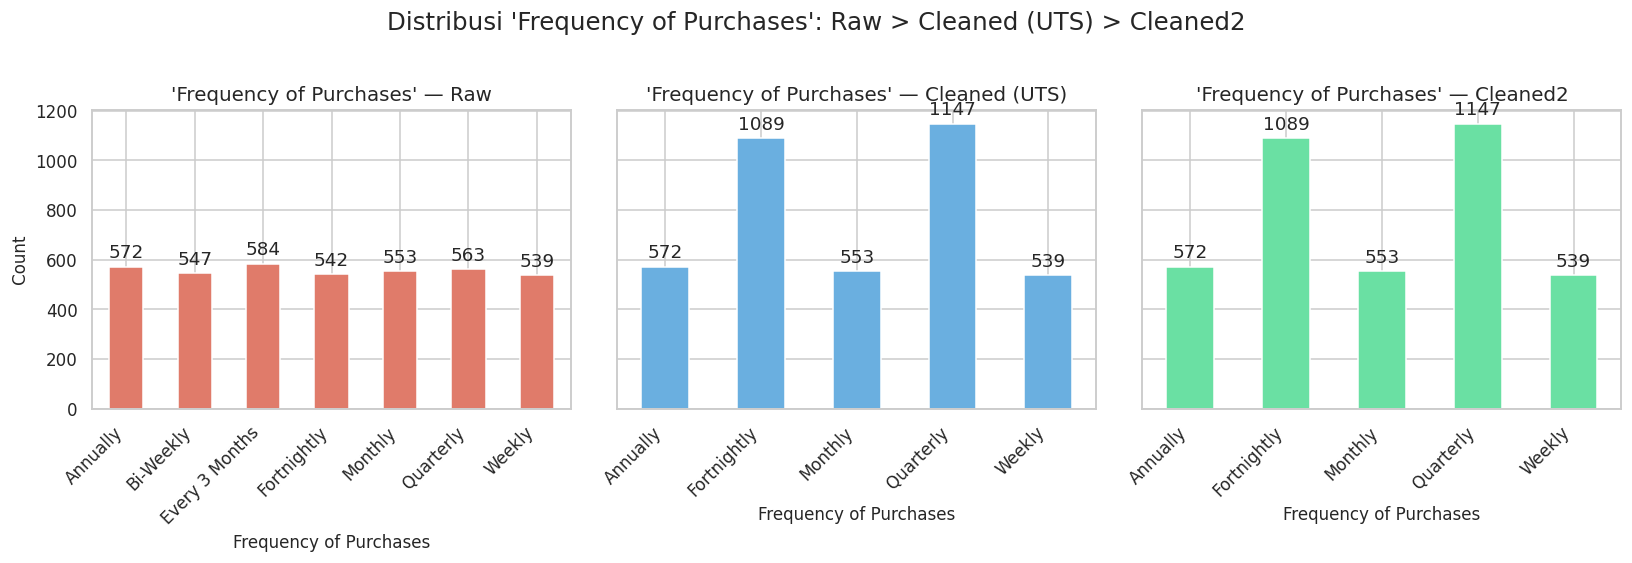

In [ ]:
col_to_plot = "Frequency of Purchases"
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

daftar_df = [raw_df, clean_df, model_df]
daftar_label = ["Raw", "Cleaned (UTS)", "Cleaned2"]
daftar_warna = [COLOR_RAW, COLOR_CLEAN, COLOR_MODEL]

for i in range(3):
    df = daftar_df[i]
    label = daftar_label[i]
    color = daftar_warna[i]
    ax = axes[i]

    data_kategori = df[col_to_plot].value_counts().sort_index()
    data_kategori.plot(kind="bar", ax=ax, color=color, edgecolor="white")
    ax.bar_label(ax.containers[0], padding=3)
    ax.set_title(f"'{col_to_plot}' — {label}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    if i == 0:
      ax.set_ylabel("Count")

fig.suptitle(
    f"Distribusi '{col_to_plot}': Raw > Cleaned (UTS) > Cleaned2",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.show()


##Evaluasi dengan Indikator Terukur

Jumlah Outlier (IQR Method):
                       Raw  Cleaned (UTS)  Cleaned2
Age                      0              0         0
Purchase Amount (USD)    0              0         0
Review Rating            0              0         0
Previous Purchases       0              0         0


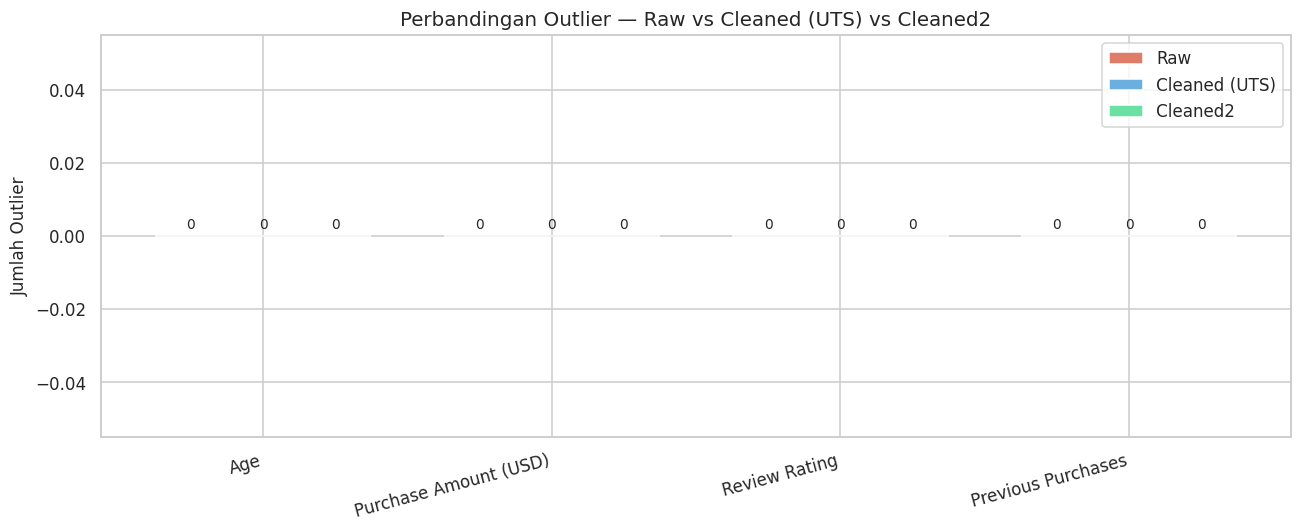

In [ ]:
def count_outliers_iqr(df, col):
    if col not in df.columns:
        return np.nan
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

outlier_df = pd.DataFrame(index=numeric_cols)
outlier_df["Raw"] = [count_outliers_iqr(raw_df, c) for c in numeric_cols]
outlier_df["Cleaned (UTS)"] = [count_outliers_iqr(clean_df, c) for c in numeric_cols]
outlier_df["Cleaned2"] = [count_outliers_iqr(model_df, c) for c in numeric_cols]
print("Jumlah Outlier (IQR Method):")
print(outlier_df.to_string())

x = np.arange(len(numeric_cols))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w, outlier_df["Raw"], w, label="Raw", color=COLOR_RAW)
b2 = ax.bar(x, outlier_df["Cleaned (UTS)"], w, label="Cleaned (UTS)", color=COLOR_CLEAN)
b3 = ax.bar(x + w, outlier_df["Cleaned2"], w, label="Cleaned2", color=COLOR_MODEL)
ax.bar_label(b1, padding=3, fontsize=9)
ax.bar_label(b2, padding=3, fontsize=9)
ax.bar_label(b3, padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(numeric_cols, rotation=15, ha="right")
ax.set_title("Perbandingan Outlier — Raw vs Cleaned (UTS) vs Cleaned2")
ax.set_ylabel("Jumlah Outlier")
ax.legend()
plt.tight_layout()
plt.show()

### Boxplot Before vs After

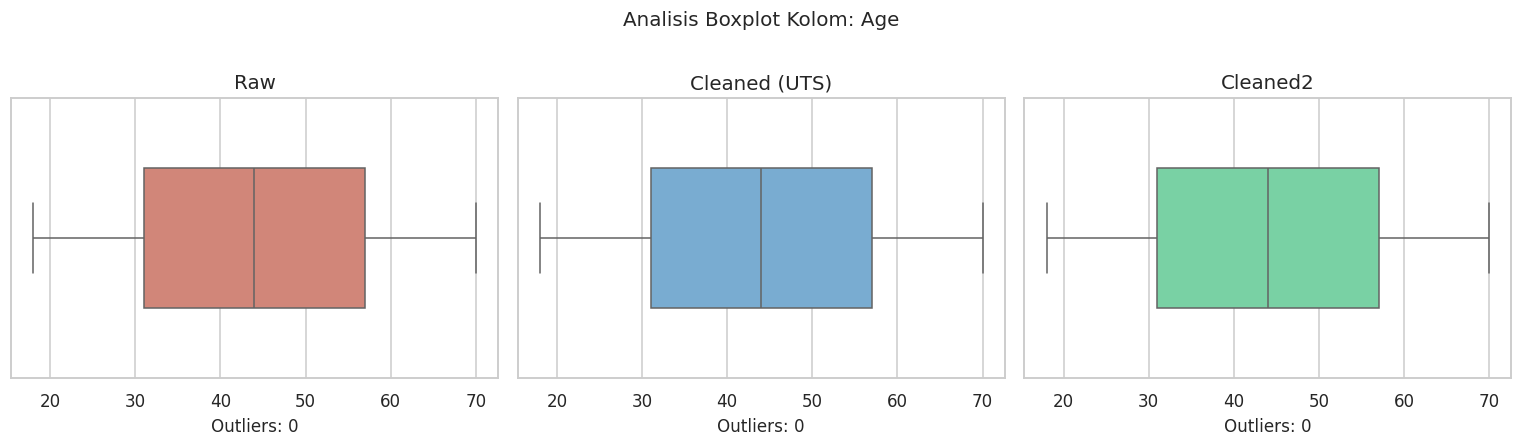

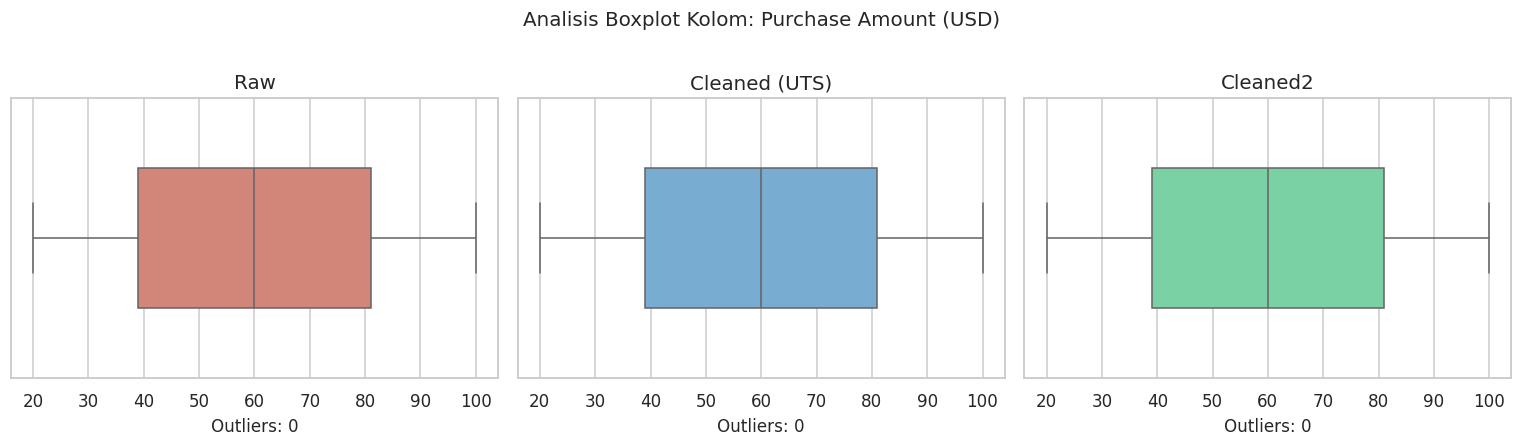

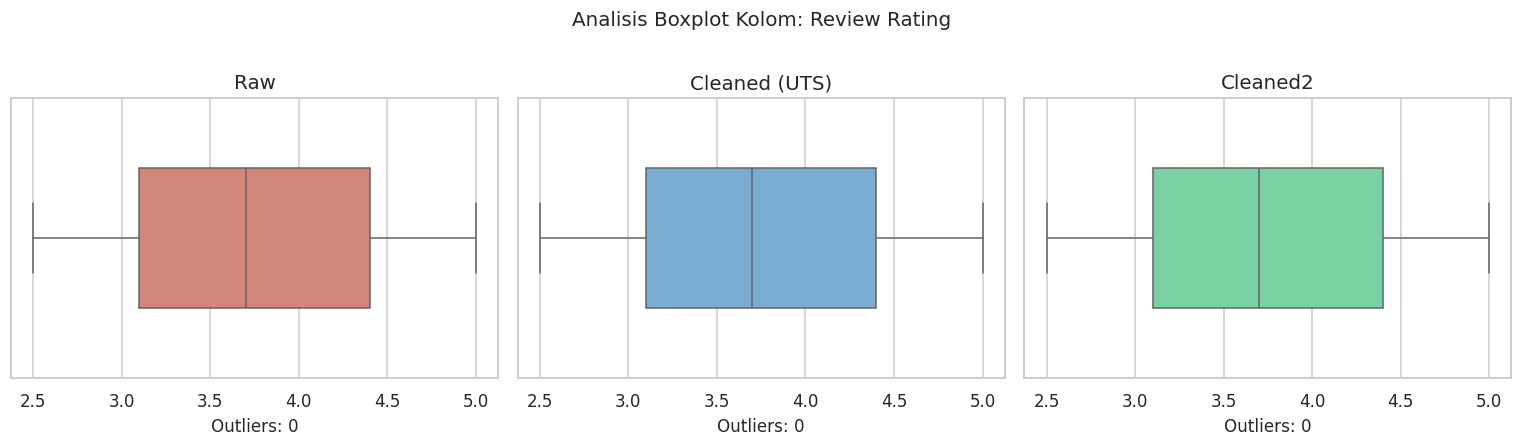

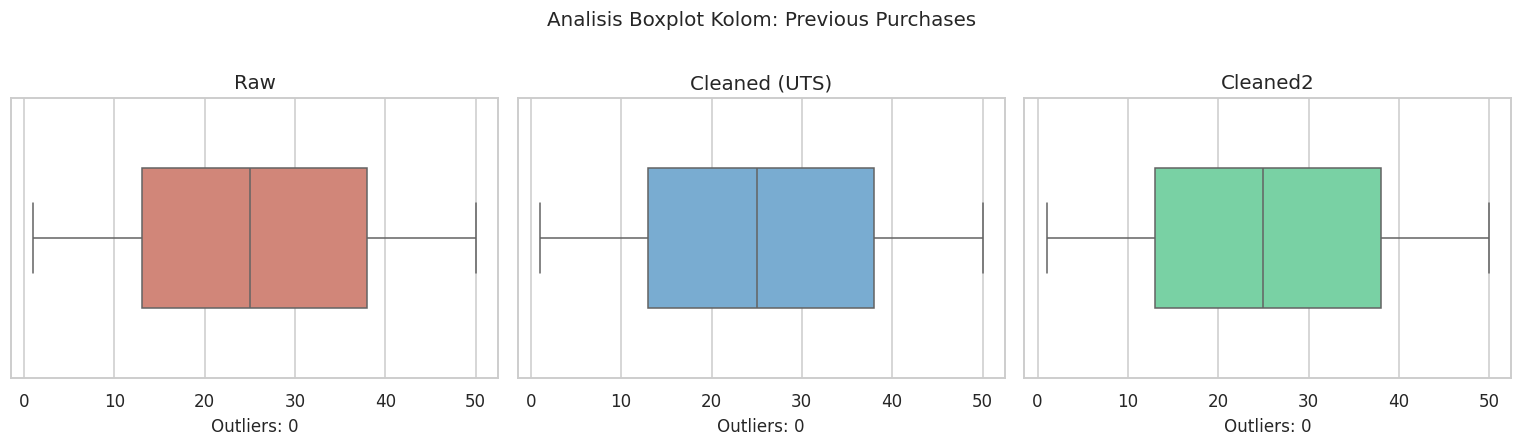

In [ ]:
for col in numeric_cols:

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    daftar_df = [raw_df, clean_df, model_df]
    daftar_label = ["Raw", "Cleaned (UTS)", "Cleaned2"]
    daftar_warna = [COLOR_RAW, COLOR_CLEAN, COLOR_MODEL]
    for i in range(3):
        df = daftar_df[i]
        label = daftar_label[i]
        color = daftar_warna[i]
        ax = axes[i]

        sns.boxplot(x=df[col], ax=ax, color=color, width=0.5)
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        jumlah_outlier = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

        ax.set_title(label)
        ax.set_xlabel(f"Outliers: {jumlah_outlier}")

    fig.suptitle(f"Analisis Boxplot Kolom: {col}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

###Distribusi Fitur Numerik

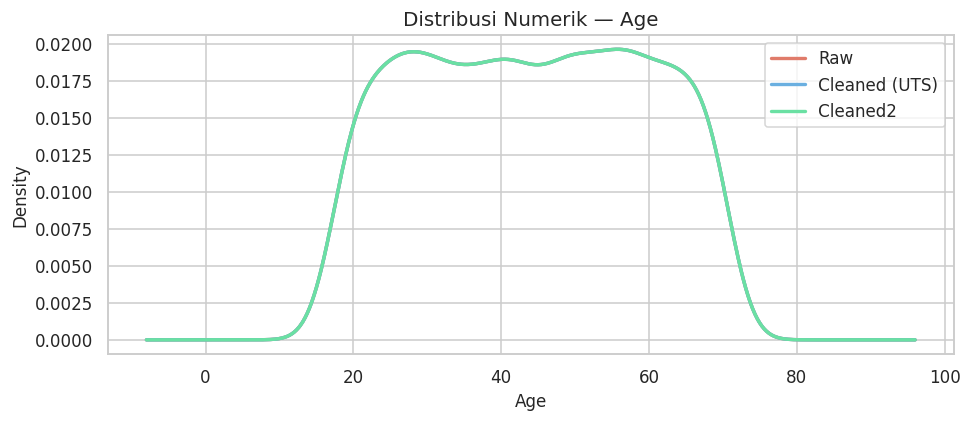

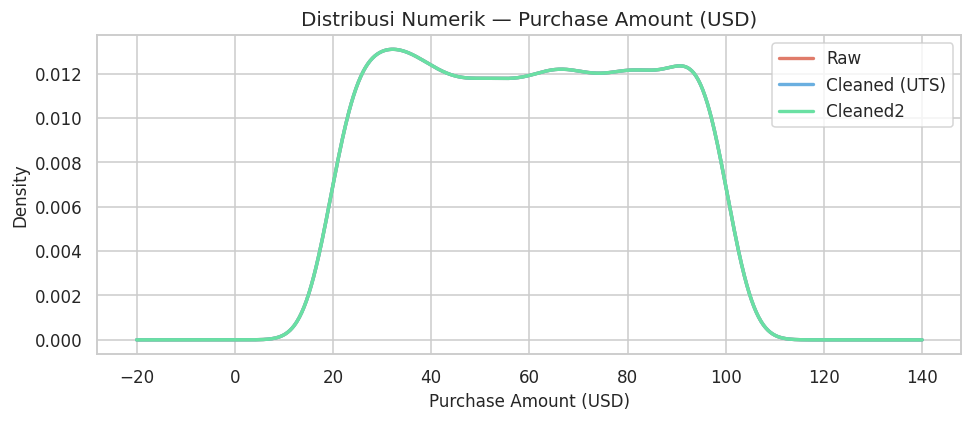

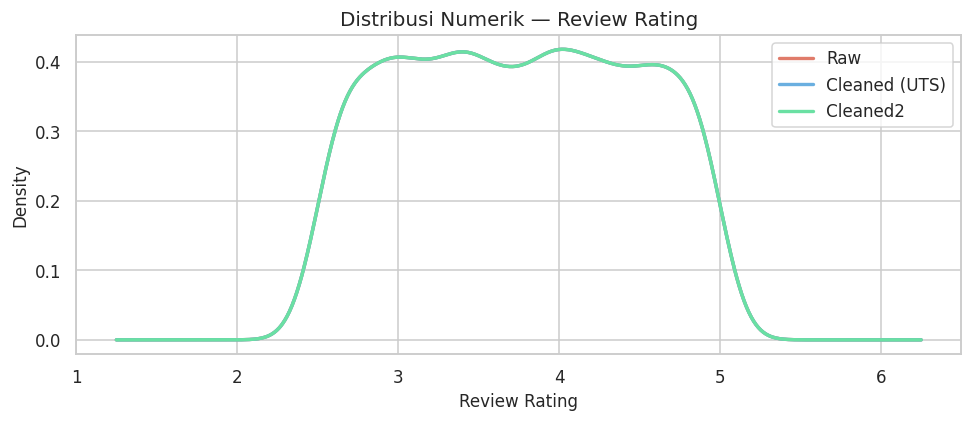

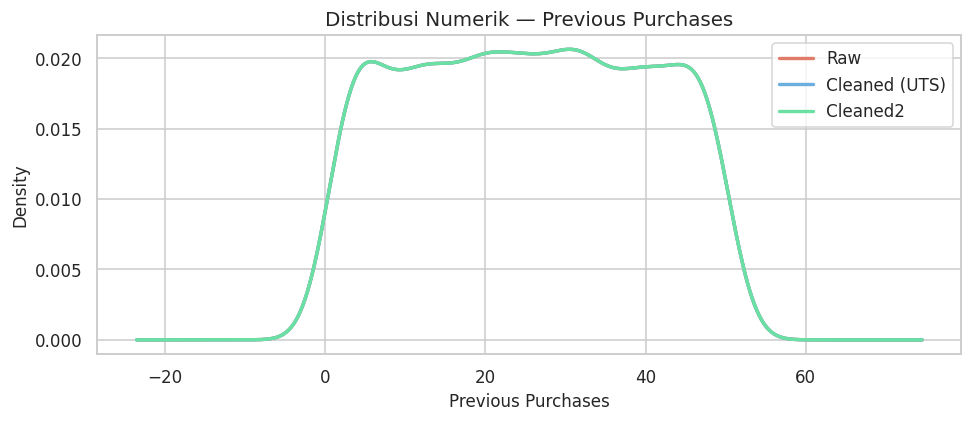

In [ ]:
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, df, color in [
        ("Raw",          raw_df,   COLOR_RAW),
        ("Cleaned (UTS)",      clean_df, COLOR_CLEAN),
        ("Cleaned2", model_df, COLOR_MODEL),
    ]:
        if col in df.columns:
            df[col].dropna().plot(
                kind="kde", ax=ax, label=label, color=color, linewidth=2.2
            )
    ax.set_title(f"Distribusi Numerik — {col}")
    ax.set_xlabel(col)
    ax.legend()
    plt.tight_layout()
    plt.show()


###Feature Engineering pada Data Final

In [ ]:
raw_cols   = set(raw_df.columns)
clean_cols = set(clean_df.columns)
model_cols = set(model_df.columns)

added_in_clean   = clean_cols - raw_cols
added_in_model   = model_cols - clean_cols
removed_in_clean = raw_cols - clean_cols


print("PERUBAHAN KOLOM")
print(f"\nKolom dihapus saat cleaning   : {sorted(removed_in_clean) or 'Tidak ada'}")
print(f"Kolom ditambah saat cleaning  : {sorted(added_in_clean)   or 'Tidak ada'}")
print(f"Kolom ditambah saat modeling  : {sorted(added_in_model)   or 'Tidak ada'}")


PERUBAHAN KOLOM

Kolom dihapus saat cleaning   : ['Color', 'Customer ID', 'Size']
Kolom ditambah saat cleaning  : ['Age Group', 'Purchase Frequency Tier']
Kolom ditambah saat modeling  : ['Customer Segment', 'Loyalty Level']


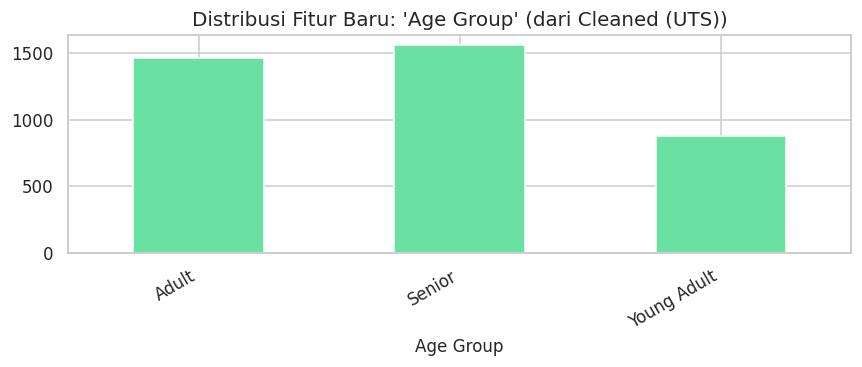

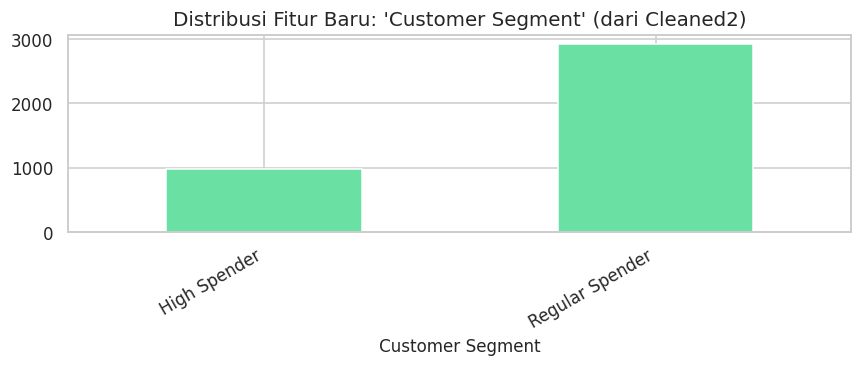

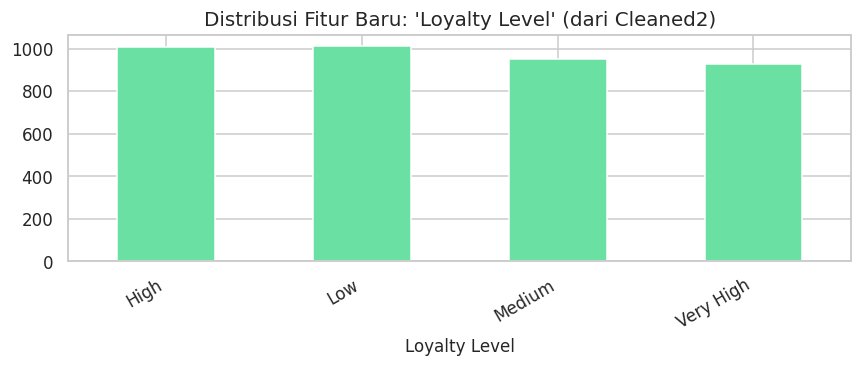

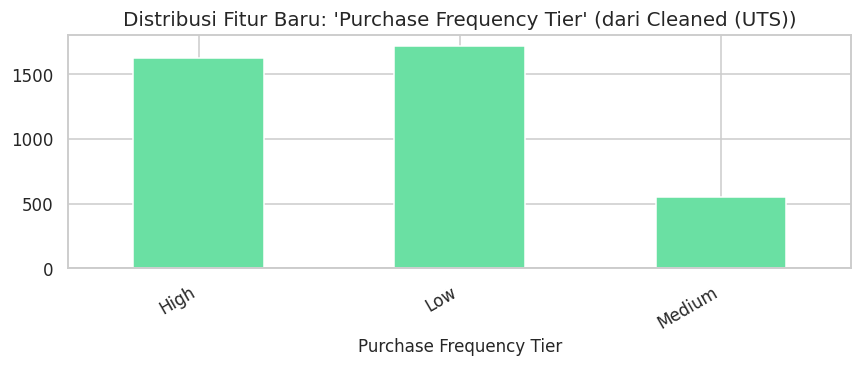

In [ ]:
all_fe_cols = sorted(list(added_in_clean | added_in_model))

for col in all_fe_cols:
    if col in clean_df.columns:
        df, label = clean_df, "Cleaned (UTS)"
    else:
        df, label = model_df, "Cleaned2"

    fig, ax = plt.subplots(figsize=(8, 3.5))

    data_plot = df[col].value_counts().sort_index()
    data_plot.plot(kind="bar", color=COLOR_MODEL, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

    ax.set_title(f"Distribusi Fitur Baru: '{col}' (dari {label})")
    plt.tight_layout()
    plt.show()

###Ringkasan Evaluasi Kualitas Data (Scorecard)

In [ ]:
def hitung_total_outlier(df):
    total = 0
    for c in numeric_cols:
        if c in df.columns:
            hasil = count_outliers_iqr(df, c)
            if not np.isnan(hasil):
                total = total + hasil
    return int(total)

mv_raw, dup_raw, out_raw = (
    raw_df.isnull().sum().sum(),
    raw_df.duplicated().sum(),
    hitung_total_outlier(raw_df),
)
mv_clean, dup_clean, out_clean = (
    clean_df.isnull().sum().sum(),
    clean_df.duplicated().sum(),
    hitung_total_outlier(clean_df),
)
mv_model, dup_model, out_model = (
    model_df.isnull().sum().sum(),
    model_df.duplicated().sum(),
    hitung_total_outlier(model_df),
)

fitur_clean = len(added_in_clean) if "added_in_clean" in locals() else 0
fitur_model = len(added_in_model) if "added_in_model" in locals() else 0

scorecard = pd.DataFrame({
    "Indikator": [
        "Total Missing Values",
        "Duplicate Rows",
        "Total Outliers (IQR)",
        "Jumlah Kolom",
        "Jumlah Fitur Baru",
    ],
    "Raw": [mv_raw, dup_raw, out_raw, raw_df.shape[1], "-"],
    "Cleaned": [mv_clean, dup_clean, out_clean, clean_df.shape[1], fitur_clean],
    "For Modeling": [
        mv_model,
        dup_model,
        out_model,
        model_df.shape[1],
        fitur_model,
    ],
})

print("SCORECARD — EVALUASI KUALITAS DATA")
print(scorecard.to_string(index=False))

print("\nDELTA (Perubahan Jumlah Baris/Data):")
print(f"Total Missing   -> Cleaned vs Raw: {mv_clean - mv_raw:+d} | Modeling vs Cleaned: {mv_model - mv_clean:+d}")
print(f"Duplicate Rows  -> Cleaned vs Raw: {dup_clean - dup_raw:+d} | Modeling vs Cleaned: {dup_model - dup_clean:+d}")
print(f"Total Outliers  -> Cleaned vs Raw: {out_clean - out_raw:+d} | Modeling vs Cleaned: {out_model - out_clean:+d}")

SCORECARD — EVALUASI KUALITAS DATA
           Indikator Raw  Cleaned  For Modeling
Total Missing Values   0        0             0
      Duplicate Rows   0        0             0
Total Outliers (IQR)   0        0             0
        Jumlah Kolom  18       17            19
   Jumlah Fitur Baru   -        2             2

DELTA (Perubahan Jumlah Baris/Data):
Total Missing   -> Cleaned vs Raw: +0 | Modeling vs Cleaned: +0
Duplicate Rows  -> Cleaned vs Raw: +0 | Modeling vs Cleaned: +0
Total Outliers  -> Cleaned vs Raw: +0 | Modeling vs Cleaned: +0



##Kesimpulan

| Aspek | Temuan |
|---|---|
| **Missing Values** | Tidak ditemukan missing value pada ketiga data |
| **Duplikasi** | Tidak ditemukan duplicate rows pada ketiga data |
| **Outlier** | Tidak ditemukan nilai outlier pada ketiga data |
| **Konsistensi Kategori** | Standarisasi kategori dilakukan saat cleaning (UTS) |
| **Feature Engineering** | Fitur baru ditambahkan di dataset cleaned2  |

> **Kesimpulan Umum:**  
> Proses data wrangling dari UTS terbukti berhasil mengatasi permasalahan dalam data berdasarkan indikator terukur di atas.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')


# Load Dataset

In [ ]:
df = pd.read_csv("shopping_behavior_cleaned.csv")
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group,Purchase Frequency Tier
0,55,Male,Blouse,Clothing,53,Kentucky,Winter,3.1,1,Express,1,1,14,Venmo,Fortnightly,Senior,High
1,19,Male,Sweater,Clothing,64,Maine,Winter,3.1,1,Express,1,1,2,Cash,Fortnightly,Young Adult,High
2,50,Male,Jeans,Clothing,73,Massachusetts,Spring,3.1,1,Free Shipping,1,1,23,Credit Card,Weekly,Senior,High
3,21,Male,Sandals,Footwear,90,Rhode Island,Spring,3.5,1,Next Day Air,1,1,49,PayPal,Weekly,Young Adult,High
4,45,Male,Blouse,Clothing,49,Oregon,Spring,2.7,1,Free Shipping,1,1,31,PayPal,Annually,Adult,Low


# Dataset Overview

In [ ]:
print("Dataset Shape:", df.shape)

display(df.head())

display(df.describe())

Dataset Shape: (3900, 17)


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group,Purchase Frequency Tier
0,55,Male,Blouse,Clothing,53,Kentucky,Winter,3.1,1,Express,1,1,14,Venmo,Fortnightly,Senior,High
1,19,Male,Sweater,Clothing,64,Maine,Winter,3.1,1,Express,1,1,2,Cash,Fortnightly,Young Adult,High
2,50,Male,Jeans,Clothing,73,Massachusetts,Spring,3.1,1,Free Shipping,1,1,23,Credit Card,Weekly,Senior,High
3,21,Male,Sandals,Footwear,90,Rhode Island,Spring,3.5,1,Next Day Air,1,1,49,PayPal,Weekly,Young Adult,High
4,45,Male,Blouse,Clothing,49,Oregon,Spring,2.7,1,Free Shipping,1,1,31,PayPal,Annually,Adult,Low


,Age,Purchase Amount (USD),Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,0.270000,0.430000,0.430000,25.351538
std,15.207589,23.685392,0.716223,0.444016,0.495139,0.495139,14.447125
min,18.000000,20.000000,2.500000,0.000000,0.000000,0.000000,1.000000
25%,31.000000,39.000000,3.100000,0.000000,0.000000,0.000000,13.000000
50%,44.000000,60.000000,3.700000,0.000000,0.000000,0.000000,25.000000
75%,57.000000,81.000000,4.400000,1.000000,1.000000,1.000000,38.000000
max,70.000000,100.000000,5.000000,1.000000,1.000000,1.000000,50.000000


# Visualization template

In [ ]:
sns.set_theme(style="whitegrid")

# Color Palette
PRIMARY_COLOR = "#4E79A7"
SECONDARY_COLOR = "#A0CBE8"
ACCENT_COLOR = "#F28E2B"

CUSTOM_PALETTE = ["#4E79A7", "#A0CBE8", "#F28E2B", "#76B7B2"]

# Figure Style
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Advanced EDA

### A. Demographic Analysis

,Gender,Subscription Status,Average Purchase,Median Purchase,Customer Count
0,Female,0,60.249199,60.0,1248
1,Male,0,59.565353,60.0,1599
2,Male,1,59.491928,60.0,1053


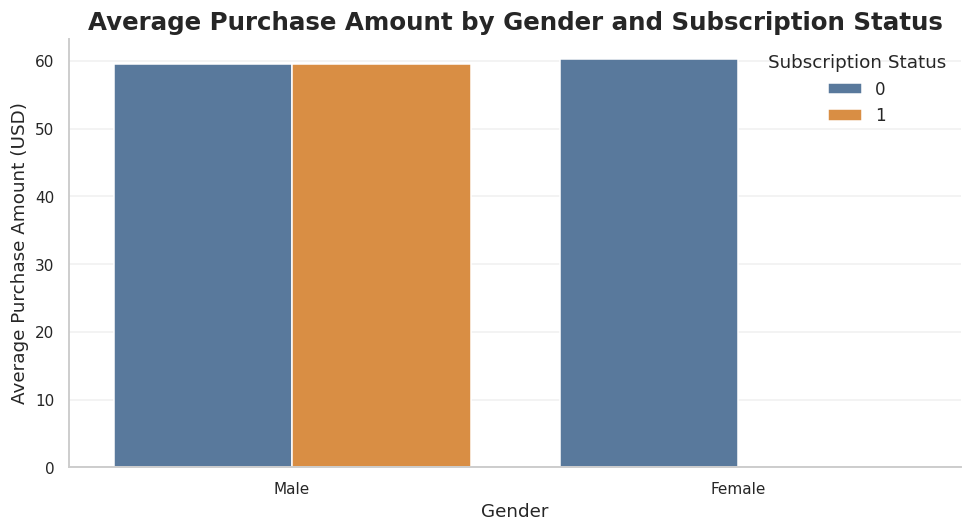

In [ ]:
gender_subscription = (
    df.groupby(['Gender', 'Subscription Status'])
    ['Purchase Amount (USD)']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

gender_subscription.columns = [
    'Gender',
    'Subscription Status',
    'Average Purchase',
    'Median Purchase',
    'Customer Count'
]

display(gender_subscription)

plt.figure(figsize=(9,5))

sns.barplot(
    data=df,
    x='Gender',
    y='Purchase Amount (USD)',
    hue='Subscription Status',
    estimator=np.mean,
    palette=["#4E79A7", "#F28E2B"],
    errorbar=None
)

plt.title('Average Purchase Amount by Gender and Subscription Status')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount (USD)')

plt.legend(title='Subscription Status')

sns.despine()

plt.tight_layout()
plt.show()

,Age Group,Purchase Frequency Tier,Purchase Amount (USD)
0,Adult,High,58.664474
1,Adult,Low,60.226266
2,Adult,Medium,58.452915
3,Senior,High,59.819876
4,Senior,Low,59.863053
5,Senior,Medium,60.383178
6,Young Adult,High,60.640957
7,Young Adult,Low,60.235751
8,Young Adult,Medium,59.077586


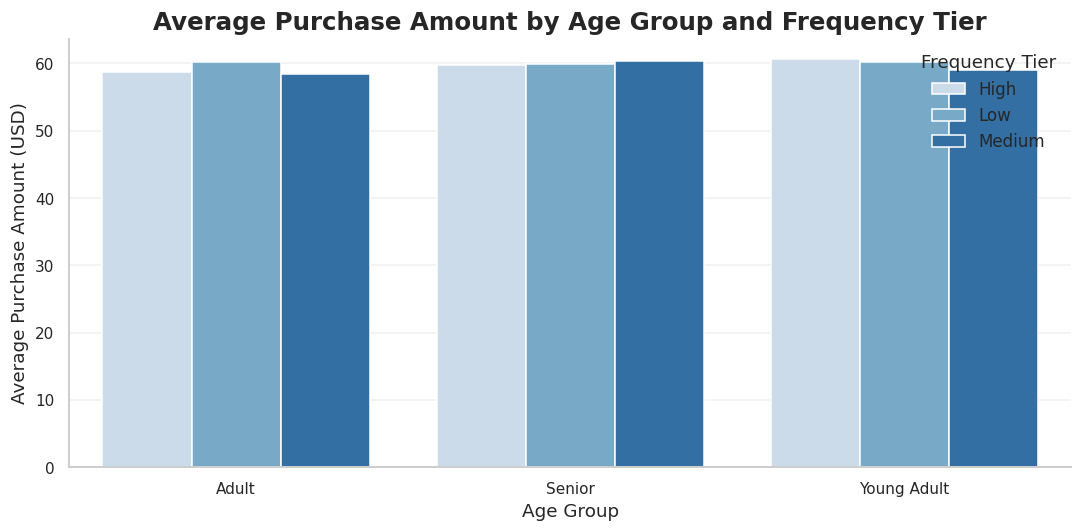

In [ ]:
# 2. Age group & Purchase Frequency Tier
age_frequency = (
    df.groupby(['Age Group', 'Purchase Frequency Tier'])
    ['Purchase Amount (USD)']
    .mean()
    .reset_index()
)

display(age_frequency)

plt.figure(figsize=(10,5))

sns.barplot(
    data=age_frequency,
    x='Age Group',
    y='Purchase Amount (USD)',
    hue='Purchase Frequency Tier',
    palette='Blues',
    errorbar=None
)

plt.title('Average Purchase Amount by Age Group and Frequency Tier')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Amount (USD)')

plt.legend(title='Frequency Tier')

sns.despine()

plt.tight_layout()
plt.show()


,Location,Purchase Amount (USD)
0,Alaska,67.597222
1,Pennsylvania,66.567568
2,Arizona,66.553846
3,West Virginia,63.876543
4,Nevada,63.379310


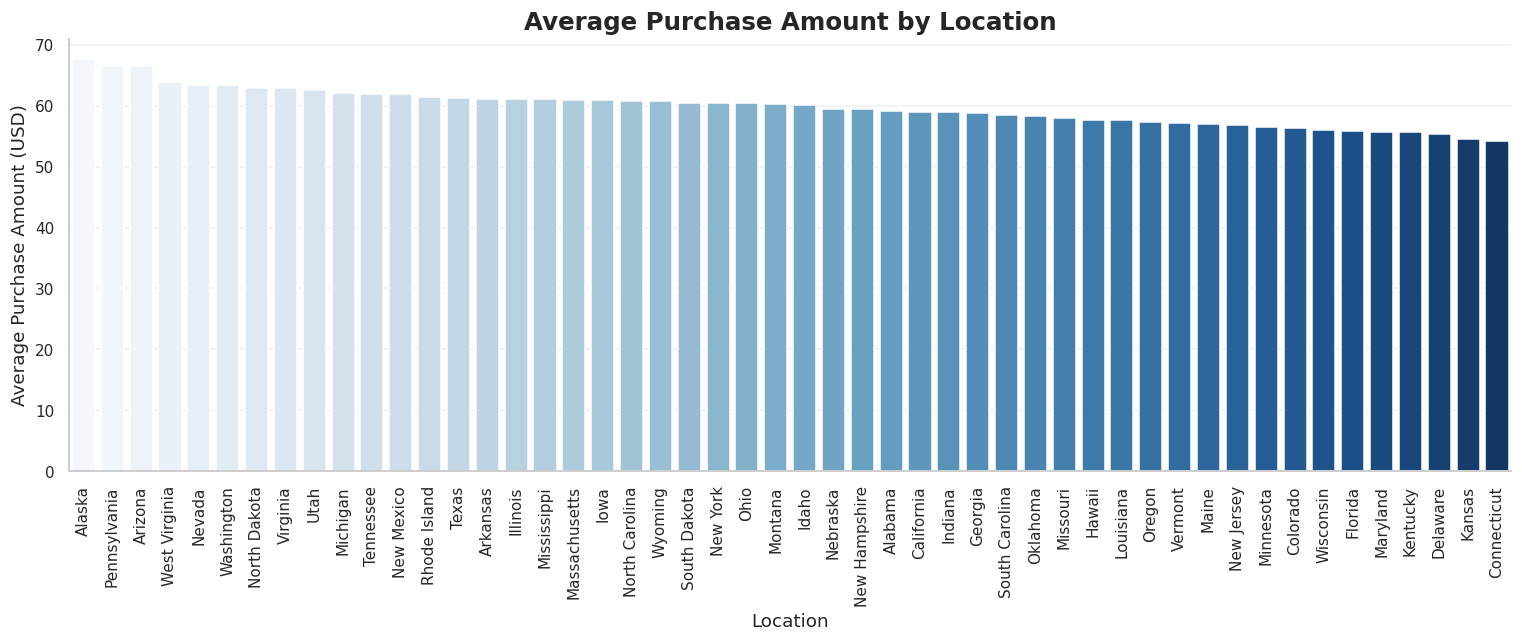

In [ ]:
# 3. Location Spending Analysis

location_spending = (
    df.groupby('Location')
    ['Purchase Amount (USD)']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(location_spending.head())

plt.figure(figsize=(14,6))

sns.barplot(
    data=location_spending,
    x='Location',
    y='Purchase Amount (USD)',
    palette='Blues'
)

plt.title('Average Purchase Amount by Location')
plt.xlabel('Location')
plt.ylabel('Average Purchase Amount (USD)')

plt.xticks(rotation=90)

sns.despine()

plt.tight_layout()
plt.show()

### B. Customer Behavioral Analysis

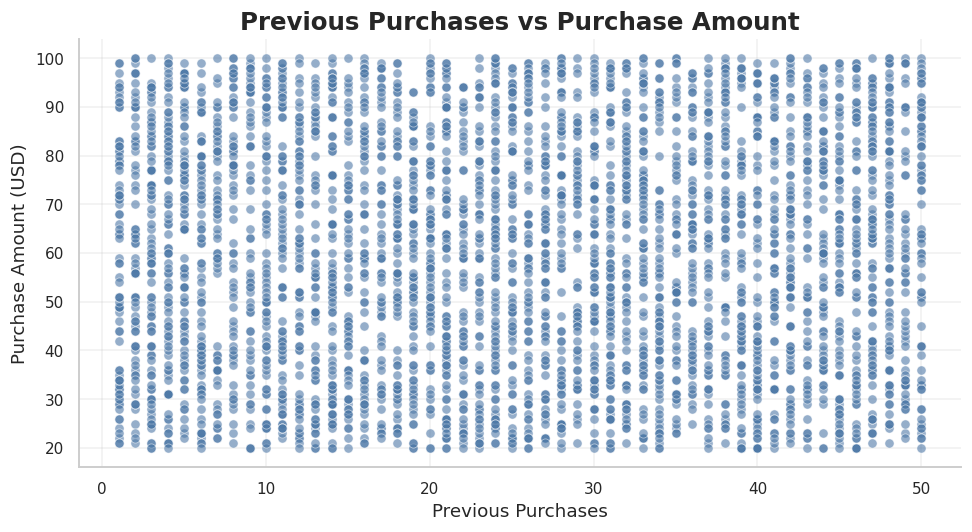

In [ ]:
# 4. Previous Purchases vs Purchase Amoun

plt.figure(figsize=(9,5))

sns.scatterplot(
    data=df,
    x='Previous Purchases',
    y='Purchase Amount (USD)',
    alpha=0.6,
    color=PRIMARY_COLOR
)

plt.title('Previous Purchases vs Purchase Amount')
plt.xlabel('Previous Purchases')
plt.ylabel('Purchase Amount (USD)')

sns.despine()

plt.tight_layout()
plt.show()


,Frequency of Purchases,Purchase Amount (USD)
0,Annually,60.173077
1,Fortnightly,59.877870
2,Monthly,59.330922
3,Quarterly,60.034002
4,Weekly,58.972171


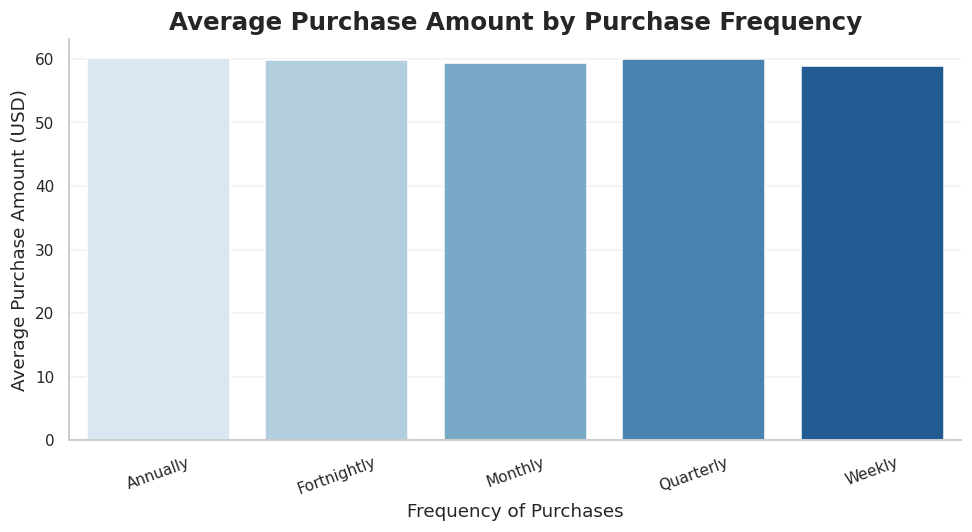

In [ ]:
# 5. Frequency of Purchases Analysis

frequency_analysis = (
    df.groupby('Frequency of Purchases')
    ['Purchase Amount (USD)']
    .mean()
    .reset_index()
)

display(frequency_analysis)

plt.figure(figsize=(9,5))

sns.barplot(
    data=frequency_analysis,
    x='Frequency of Purchases',
    y='Purchase Amount (USD)',
    palette='Blues'
)

plt.title('Average Purchase Amount by Purchase Frequency')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount (USD)')

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()
plt.show()

Purchase Frequency Tier,High,Low,Medium
Subscription Status,,,
0,1178,1265,404
1,450,454,149


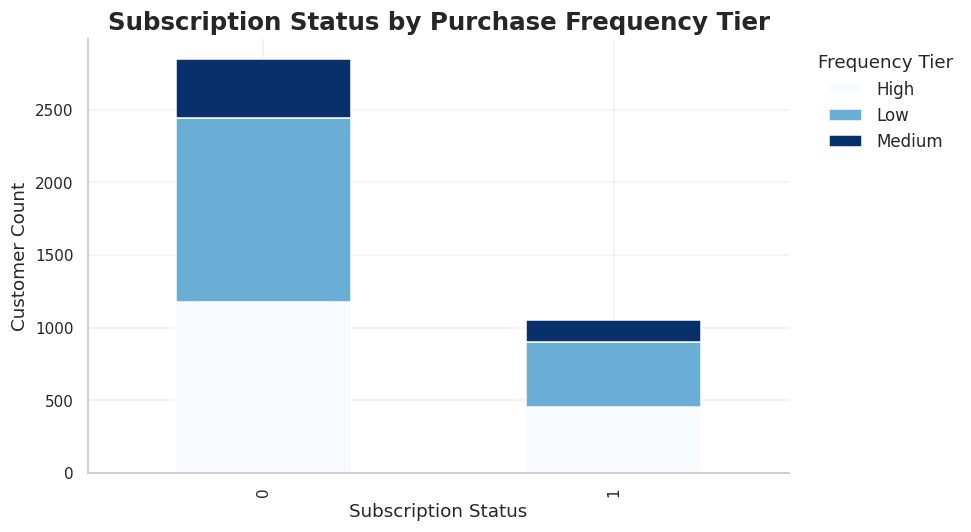

In [ ]:
# 6. Subscription Status vs Frequency Tier

subscription_frequency = pd.crosstab(
    df['Subscription Status'],
    df['Purchase Frequency Tier']
)

display(subscription_frequency)

subscription_frequency.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5),
    colormap='Blues'
)

plt.title('Subscription Status by Purchase Frequency Tier')
plt.xlabel('Subscription Status')
plt.ylabel('Customer Count')

plt.legend(
    title='Frequency Tier',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

### C. Spending Pattern Analysis


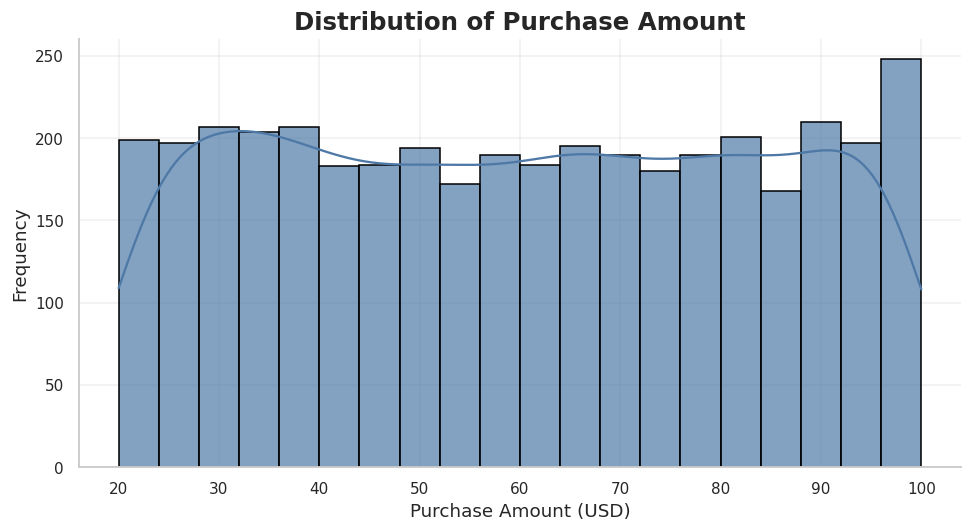

In [ ]:
# 7. Purchase Amount Distribution

plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='Purchase Amount (USD)',
    bins=20,
    kde=True,
    color=PRIMARY_COLOR,
    edgecolor='black',
    alpha=0.7
)

plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')

sns.despine()

plt.tight_layout()
plt.show()


,Discount Applied,mean,median,count
0,0,60.130454,60.0,2223
1,1,59.279070,60.0,1677


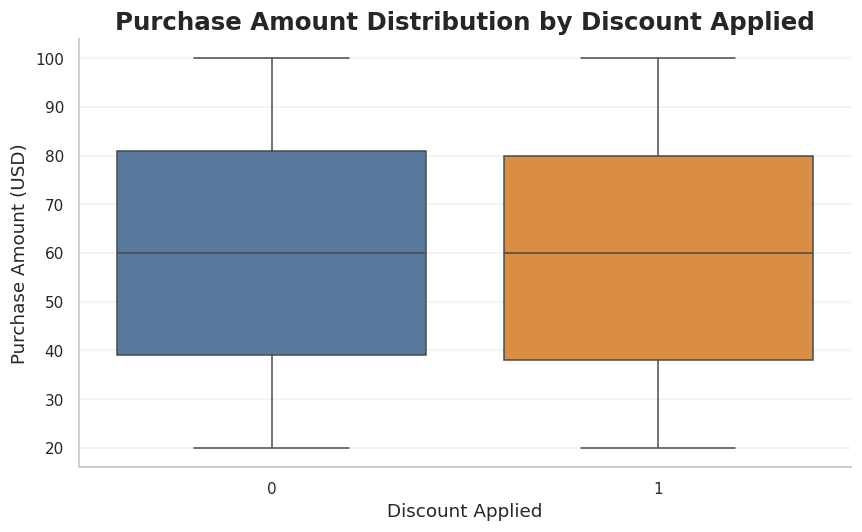

In [ ]:
# 8. Discount Applied Analysis

discount_analysis = (
    df.groupby('Discount Applied')
    ['Purchase Amount (USD)']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

display(discount_analysis)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Discount Applied',
    y='Purchase Amount (USD)',
    palette=["#4E79A7", "#F28E2B"],
    fliersize=3
)

plt.title('Purchase Amount Distribution by Discount Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Purchase Amount (USD)')

sns.despine()

plt.tight_layout()
plt.show()


,Promo Code Used,Discount Applied,Purchase Amount (USD)
0,0,0,60.130454
1,1,1,59.279070


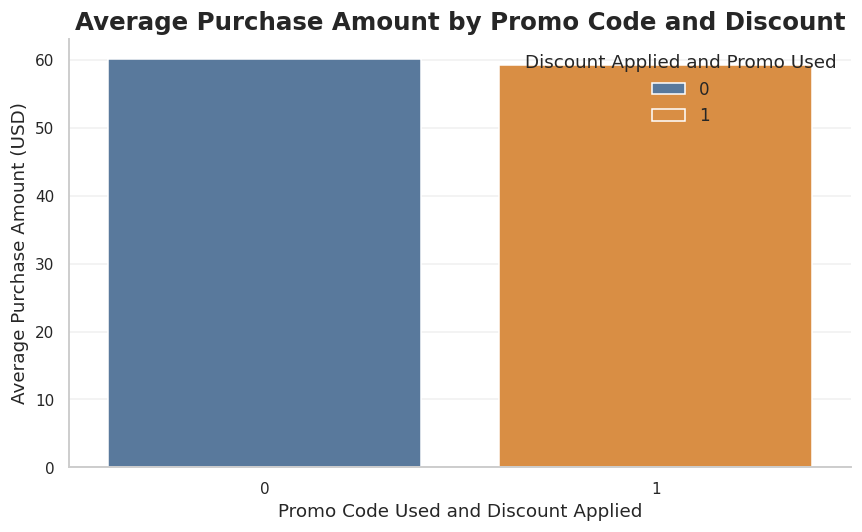

In [ ]:
# 9. Promo Code & Discount Analysis

promo_discount = (
    df.groupby(['Promo Code Used', 'Discount Applied'])
    ['Purchase Amount (USD)']
    .mean()
    .reset_index()
)

display(promo_discount)

plt.figure(figsize=(8,5))

sns.barplot(
    data=promo_discount,
    x='Promo Code Used',
    y='Purchase Amount (USD)',
    hue='Discount Applied',
    palette=["#4E79A7", "#F28E2B"],
    errorbar=None
)

plt.title('Average Purchase Amount by Promo Code and Discount')
plt.xlabel('Promo Code Used and Discount Applied')
plt.ylabel('Average Purchase Amount (USD)')

plt.legend(title='Discount Applied and Promo Used')

sns.despine()

plt.tight_layout()
plt.show()

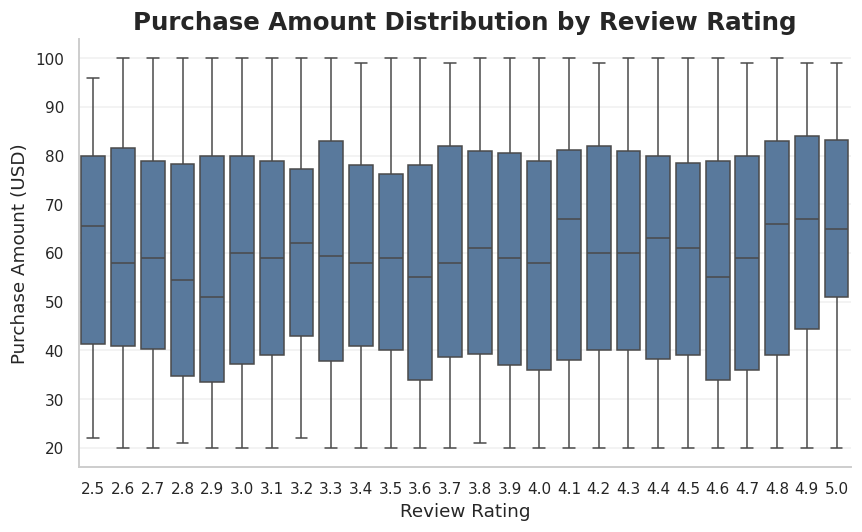

In [ ]:
# 10. Review Rating vs Purchase Amount

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Review Rating',
    y='Purchase Amount (USD)',
    color=PRIMARY_COLOR,
    fliersize=3
)

plt.title('Purchase Amount Distribution by Review Rating')
plt.xlabel('Review Rating')
plt.ylabel('Purchase Amount (USD)')

sns.despine()

plt.tight_layout()
plt.show()

,Customer Segment,mean,count
0,High Spender,90.554192,978
1,Regular Spender,49.458932,2922


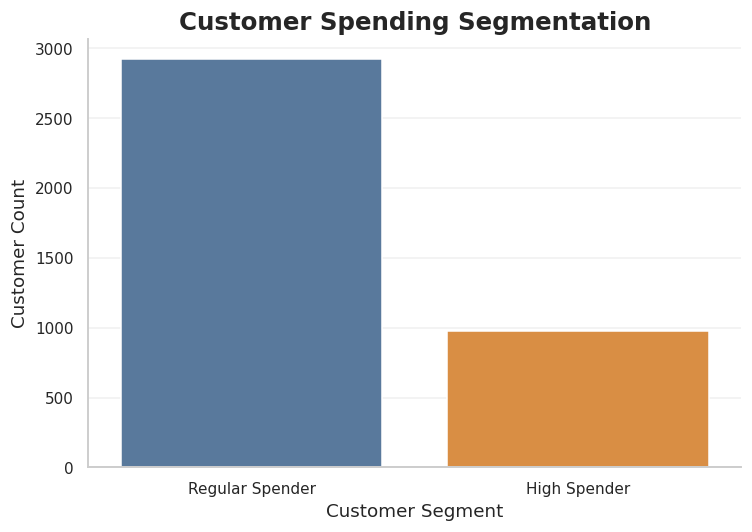

In [ ]:
# 11. High Spender Identification

high_spender_threshold = df['Purchase Amount (USD)'].quantile(0.75)

df['Customer Segment'] = np.where(
    df['Purchase Amount (USD)'] >= high_spender_threshold,
    'High Spender',
    'Regular Spender'
)

segment_summary = (
    df.groupby('Customer Segment')
    ['Purchase Amount (USD)']
    .agg(['mean', 'count'])
    .reset_index()
)

display(segment_summary)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Customer Segment',
    palette=["#4E79A7", "#F28E2B"]
)

plt.title('Customer Spending Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Customer Count')

sns.despine()

plt.tight_layout()
plt.show()


### D. Product and Category Analysis

,Category,Purchase Amount (USD)
0,Footwear,60.255426
1,Clothing,60.025331
2,Accessories,59.838710
3,Outerwear,57.172840


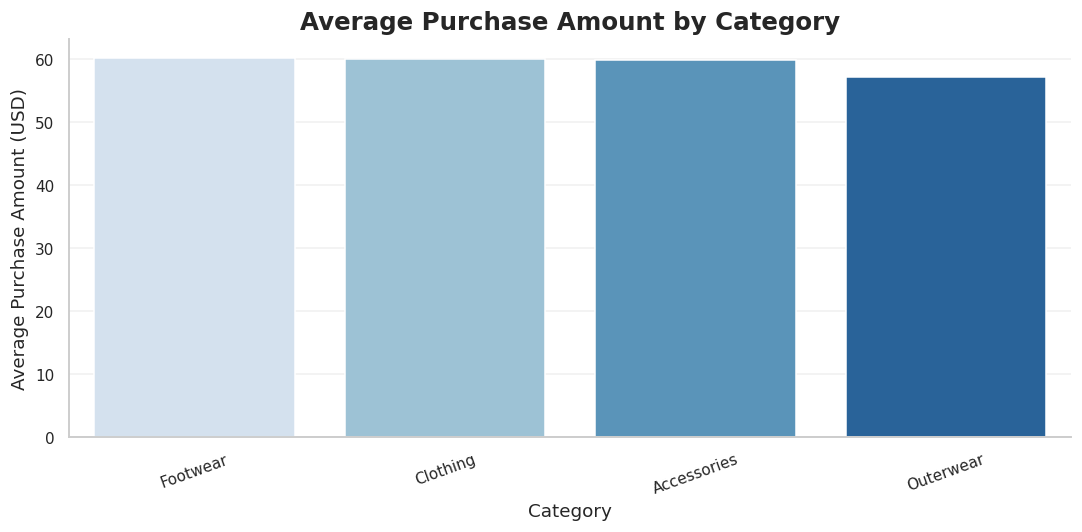

In [ ]:
# 12. Category Spending Analysis

category_spending = (
    df.groupby('Category')
    ['Purchase Amount (USD)']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(category_spending)

plt.figure(figsize=(10,5))

sns.barplot(
    data=category_spending,
    x='Category',
    y='Purchase Amount (USD)',
    palette='Blues'
)

plt.title('Average Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Average Purchase Amount (USD)')

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()
plt.show()

,Season,Category,Total Purchases
0,Fall,Accessories,324
1,Fall,Clothing,427
2,Fall,Footwear,136
3,Fall,Outerwear,88
4,Spring,Accessories,301
5,Spring,Clothing,454
6,Spring,Footwear,163
7,Spring,Outerwear,81
8,Summer,Accessories,312
9,Summer,Clothing,408


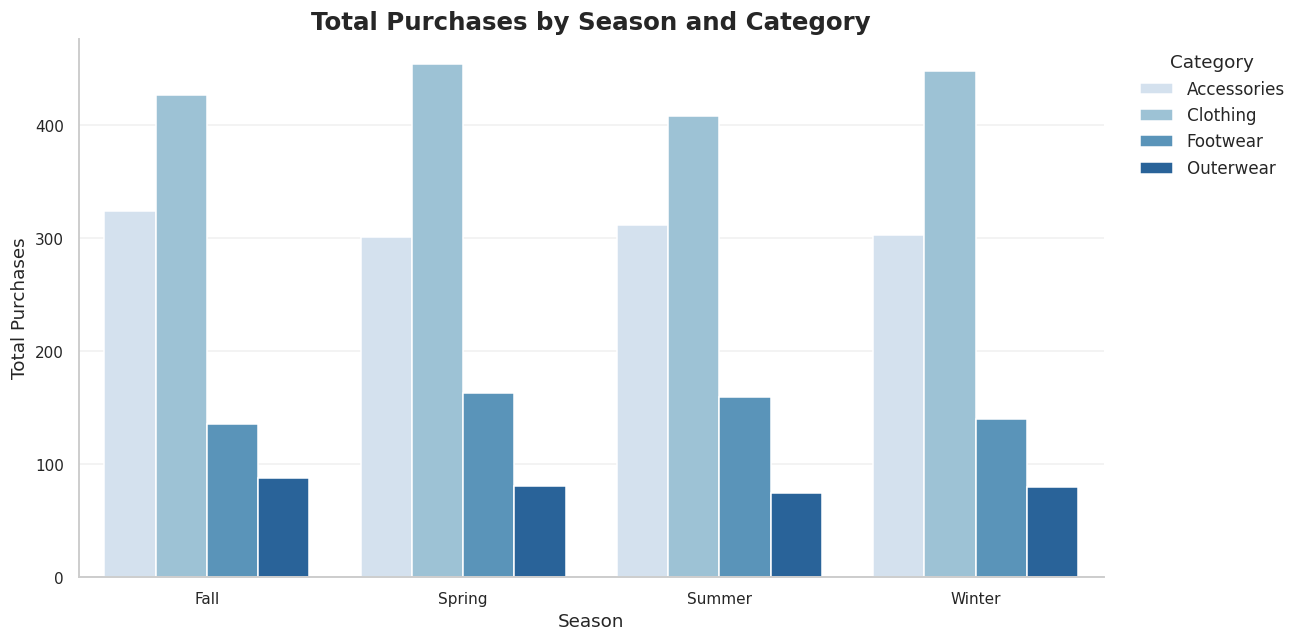

In [ ]:
# 13. Seasonal Category Analysis
season_category = (
    df.groupby(['Season', 'Category'])
    .size()
    .reset_index(name='Total Purchases')
)

display(season_category)

plt.figure(figsize=(12,6))

sns.barplot(
    data=season_category,
    x='Season',
    y='Total Purchases',
    hue='Category',
    palette='Blues'
)

plt.title('Total Purchases by Season and Category')
plt.xlabel('Season')
plt.ylabel('Total Purchases')

plt.legend(
    title='Category',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

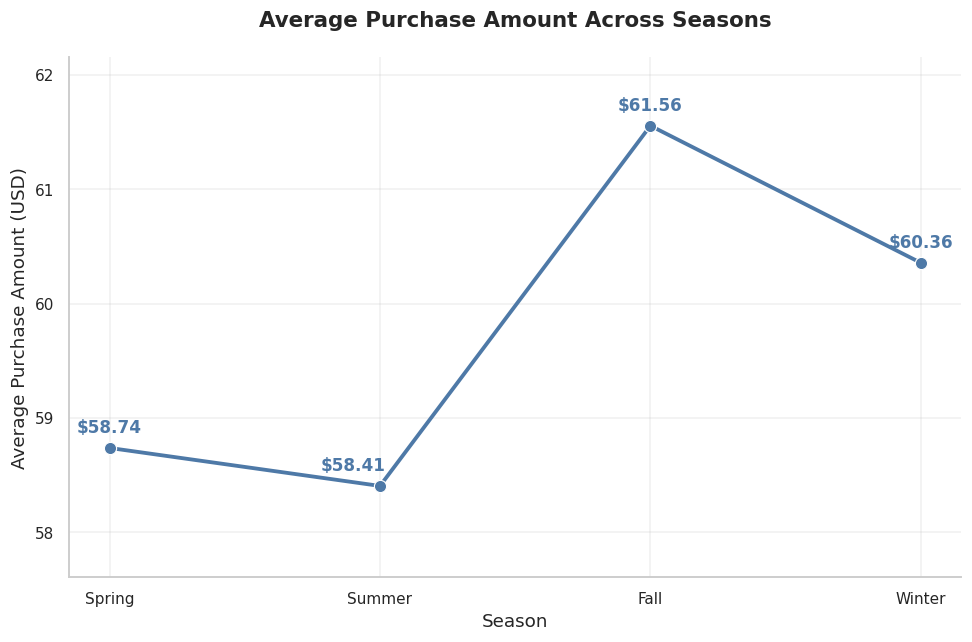

In [ ]:
season_spending = (
    df.groupby('Season')
    ['Purchase Amount (USD)']
    .mean()
    .reset_index()
)

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_spending['Season'] = pd.Categorical(
    season_spending['Season'],
    categories=season_order,
    ordered=True
)
season_spending = season_spending.sort_values('Season').reset_index(drop=True)

plt.figure(figsize=(9, 6))

ax = sns.lineplot(
    data=season_spending,
    x='Season',
    y='Purchase Amount (USD)',
    marker='o',
    markersize=8,
    linewidth=2.5,
    color=PRIMARY_COLOR
)

for i, val in enumerate(season_spending['Purchase Amount (USD)']):
    x_pos = i - 0.1 if season_spending['Season'].iloc[i] == 'Summer' else i
    ax.text(
        x=x_pos,
        y=val + 0.1,
        s=f"${val:.2f}",
        color=PRIMARY_COLOR,
        ha="center",
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )
plt.title('Average Purchase Amount Across Seasons', fontsize=14, pad=20)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Purchase Amount (USD)', fontsize=12)

plt.ylim(
    season_spending['Purchase Amount (USD)'].min() - 0.8,
    season_spending['Purchase Amount (USD)'].max() + 0.6
)

sns.despine()
plt.tight_layout()
plt.show()

,Item Purchased,Total Purchases
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


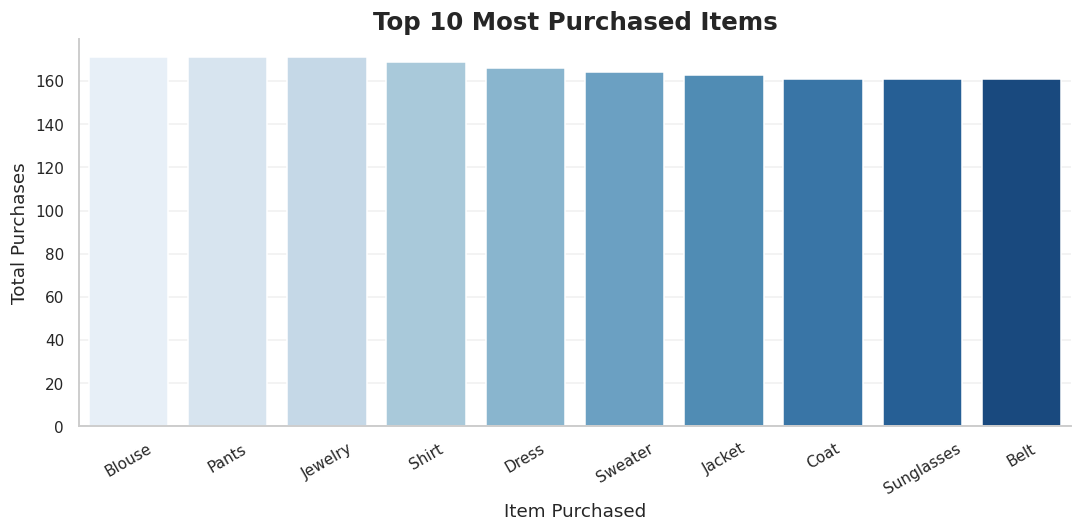

In [ ]:
# 15. Top Purchased Items Analysis

top_items = (
    df['Item Purchased']
    .value_counts()
    .head(10)
    .reset_index()
)

top_items.columns = ['Item Purchased', 'Total Purchases']

display(top_items)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_items,
    x='Item Purchased',
    y='Total Purchases',
    palette='Blues'
)

plt.title('Top 10 Most Purchased Items')
plt.xlabel('Item Purchased')
plt.ylabel('Total Purchases')

plt.xticks(rotation=30)

sns.despine()

plt.tight_layout()
plt.show()

### E. Transaction and Payment analysis

,Payment Method,Purchase Amount (USD)
0,Debit Card,60.915094
1,Credit Card,60.074516
2,Bank Transfer,59.712418
3,Cash,59.704478
4,PayPal,59.245199
5,Venmo,58.949527


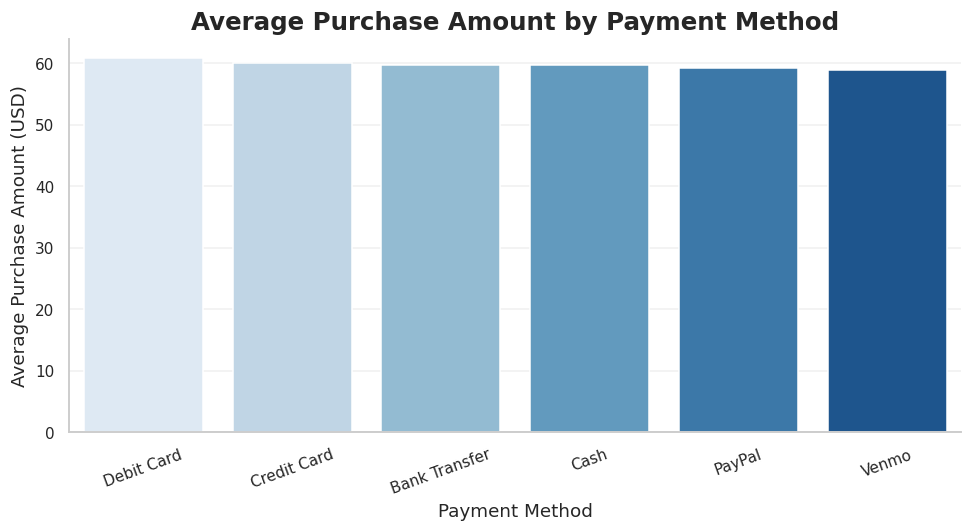

In [ ]:
# 16. Payment Method Analysis

payment_analysis = (
    df.groupby('Payment Method')
    ['Purchase Amount (USD)']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(payment_analysis)

plt.figure(figsize=(9,5))

sns.barplot(
    data=payment_analysis,
    x='Payment Method',
    y='Purchase Amount (USD)',
    palette='Blues'
)

plt.title('Average Purchase Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Purchase Amount (USD)')

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()
plt.show()


,Shipping Type,mean,count
0,2-Day Shipping,60.733652,627
1,Express,60.475232,646
2,Free Shipping,60.410370,675
3,Next Day Air,58.631173,648
4,Standard,58.460245,654
5,Store Pickup,59.893846,650


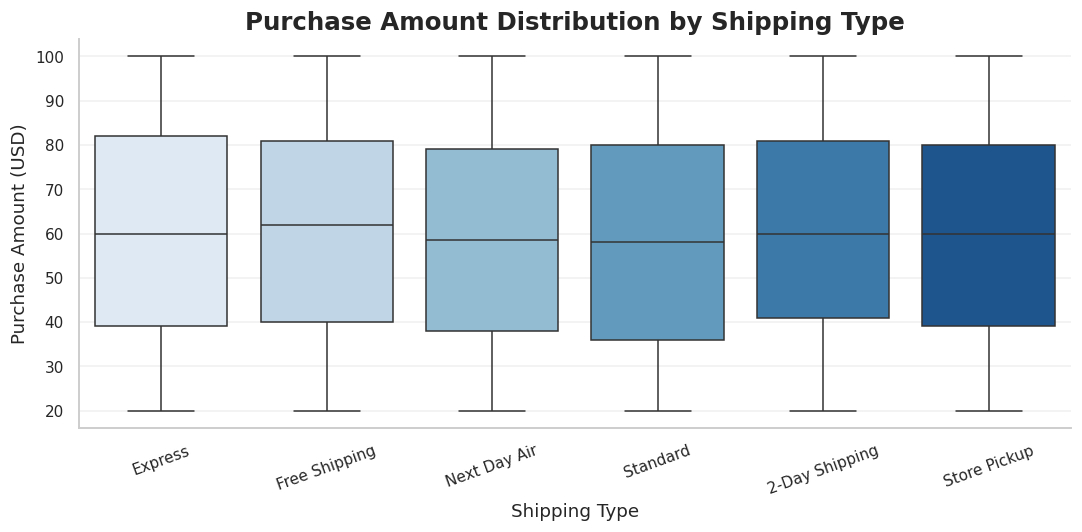

In [ ]:
# 17. Shipping Type Analysis

shipping_analysis = (
    df.groupby('Shipping Type')
    ['Purchase Amount (USD)']
    .agg(['mean', 'count'])
    .reset_index()
)

display(shipping_analysis)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Shipping Type',
    y='Purchase Amount (USD)',
    palette='Blues',
    fliersize=3
)

plt.title('Purchase Amount Distribution by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Purchase Amount (USD)')

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()
plt.show()


# Advanced Relationship Analysis


### A. Correlation Analysis

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Subscription Status,Discount Applied,Promo Code Used
Age,1.000000,-0.010424,-0.021949,0.040445,0.006492,0.004366,0.004366
Purchase Amount (USD),-0.010424,1.000000,0.030776,0.008063,-0.006996,-0.017798,-0.017798
Review Rating,-0.021949,0.030776,1.000000,0.004229,-0.006368,-0.012486,-0.012486
Previous Purchases,0.040445,0.008063,0.004229,1.000000,0.030859,0.023537,0.023537
Subscription Status,0.006492,-0.006996,-0.006368,0.030859,1.000000,0.700202,0.700202
Discount Applied,0.004366,-0.017798,-0.012486,0.023537,0.700202,1.000000,1.000000
Promo Code Used,0.004366,-0.017798,-0.012486,0.023537,0.700202,1.000000,1.000000


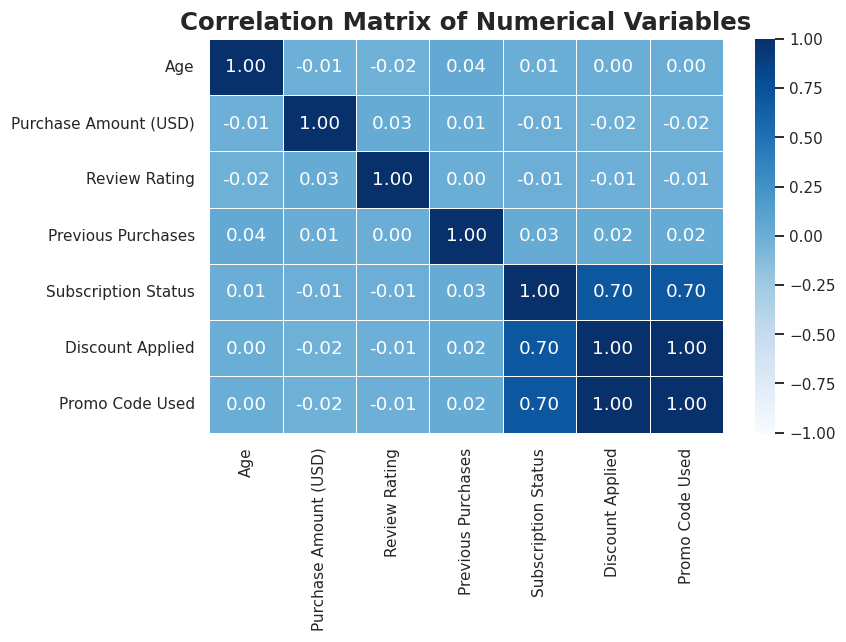

In [ ]:
numeric_columns = [
    'Age',
    'Purchase Amount (USD)',
    'Review Rating',
    'Previous Purchases',
    'Subscription Status',
    'Discount Applied',
    'Promo Code Used'
]

correlation_matrix = df[numeric_columns].corr()

display(correlation_matrix)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

### B. Category and season pivot analysis

Season,Fall,Spring,Summer,Winter
Category,,,,
Accessories,61.339506,56.501661,60.987179,60.366337
Clothing,61.405152,60.995595,56.563725,60.879464
Footwear,63.713235,58.619632,58.706250,60.571429
Outerwear,59.761364,54.629630,57.040000,57.025000


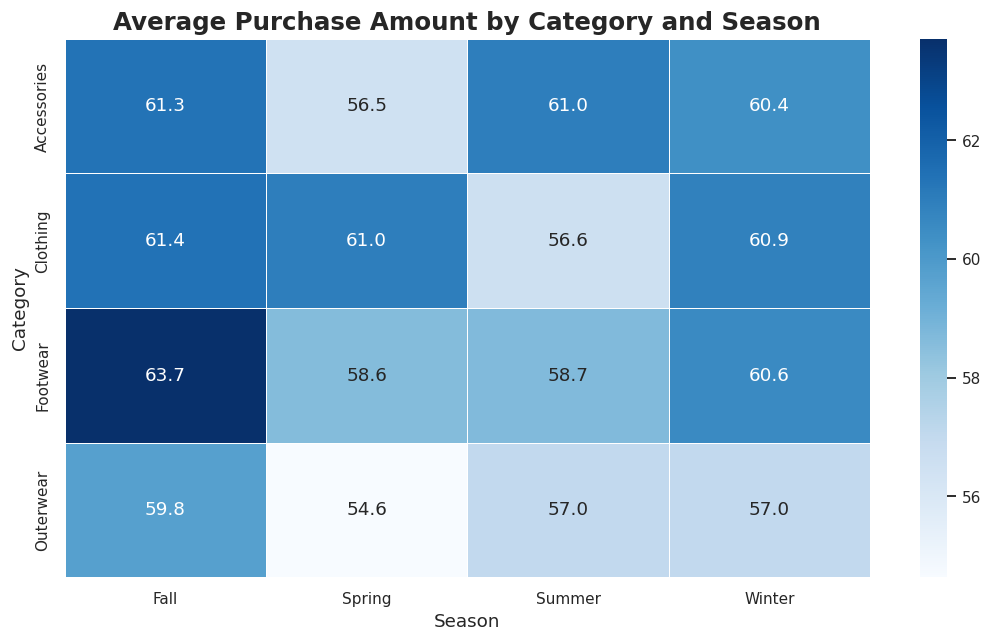

In [ ]:
pivot_analysis = pd.pivot_table(
    df,
    values='Purchase Amount (USD)',
    index='Category',
    columns='Season',
    aggfunc='mean'
)

display(pivot_analysis)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_analysis,
    annot=True,
    cmap='Blues',
    fmt='.1f',
    linewidths=0.5
)

plt.title('Average Purchase Amount by Category and Season')

plt.tight_layout()
plt.show()

### C. Infuential Variable Analysis

,Variable,Correlation with Purchase Amount
1,Purchase Amount (USD),1.000000
2,Review Rating,0.030776
3,Previous Purchases,0.008063
4,Subscription Status,-0.006996
0,Age,-0.010424
5,Discount Applied,-0.017798
6,Promo Code Used,-0.017798


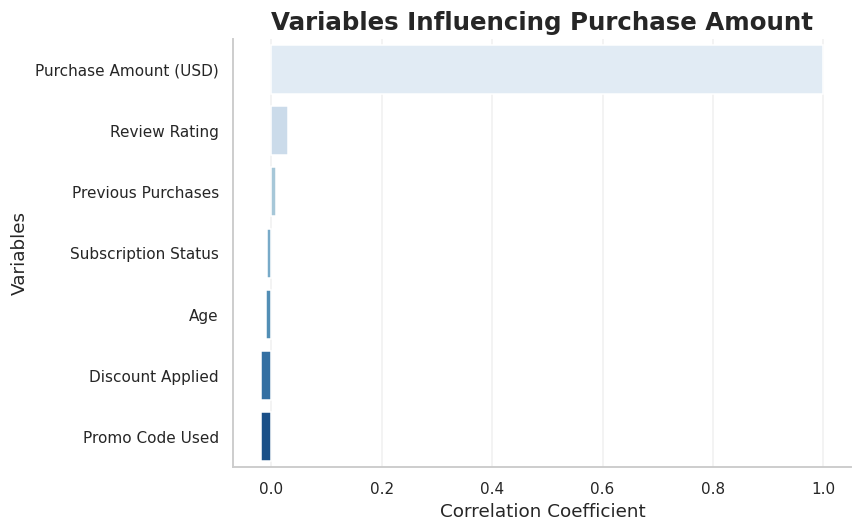

In [ ]:
influential_summary = pd.DataFrame({
    'Variable': correlation_matrix['Purchase Amount (USD)'].index,
    'Correlation with Purchase Amount':
    correlation_matrix['Purchase Amount (USD)'].values
})

influential_summary = influential_summary.sort_values(
    by='Correlation with Purchase Amount',
    ascending=False
)

display(influential_summary)

plt.figure(figsize=(8,5))

sns.barplot(
    data=influential_summary,
    x='Correlation with Purchase Amount',
    y='Variable',
    palette='Blues'
)

plt.title('Variables Influencing Purchase Amount')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variables')

sns.despine()

plt.tight_layout()
plt.show()

### D. Subscription Status vs Spending Behavior

,Subscription Status,mean,median,std,count
0,0,59.865121,60.0,23.775199,2847
1,1,59.491928,60.0,23.449914,1053


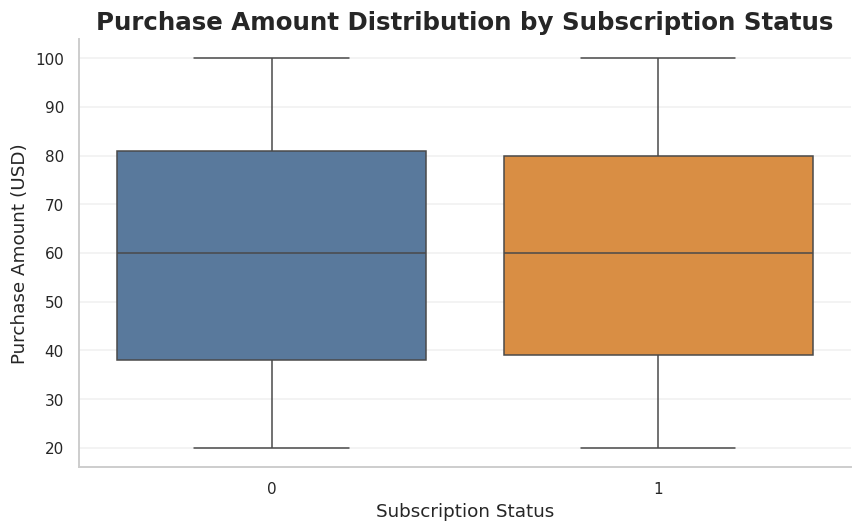

In [ ]:
subscription_spending = (
    df.groupby('Subscription Status')
    ['Purchase Amount (USD)']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)

display(subscription_spending)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Subscription Status',
    y='Purchase Amount (USD)',
    palette=["#4E79A7", "#F28E2B"],
    fliersize=3
)

plt.title('Purchase Amount Distribution by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Purchase Amount (USD)')

sns.despine()

plt.tight_layout()
plt.show()

### E. Loyalty vs spending relationship

,Loyalty Level,mean,median,count
0,Low,60.138067,60.0,1014
1,Medium,59.031546,59.0,951
2,High,59.885799,60.0,1007
3,Very High,59.975216,60.0,928


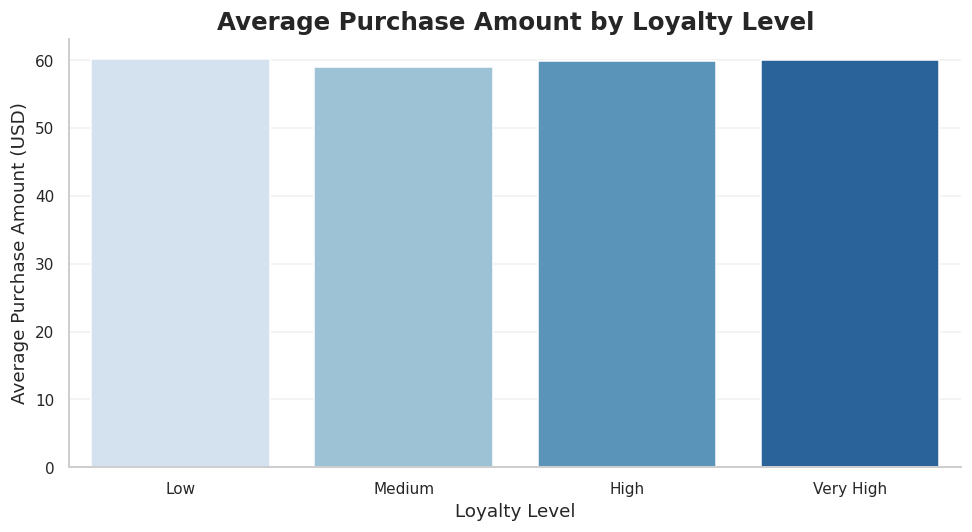

In [ ]:
loyalty_group = pd.qcut(
    df['Previous Purchases'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

df['Loyalty Level'] = loyalty_group

loyalty_analysis = (
    df.groupby('Loyalty Level')
    ['Purchase Amount (USD)']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

display(loyalty_analysis)

plt.figure(figsize=(9,5))

sns.barplot(
    data=loyalty_analysis,
    x='Loyalty Level',
    y='mean',
    palette='Blues'
)

plt.title('Average Purchase Amount by Loyalty Level')
plt.xlabel('Loyalty Level')
plt.ylabel('Average Purchase Amount (USD)')

sns.despine()

plt.tight_layout()
plt.show()

### F. Discount and Purchase Frequency Relationship


Purchase Frequency Tier,High,Low,Medium
Discount Applied,,,
0,925,982,316
1,703,737,237


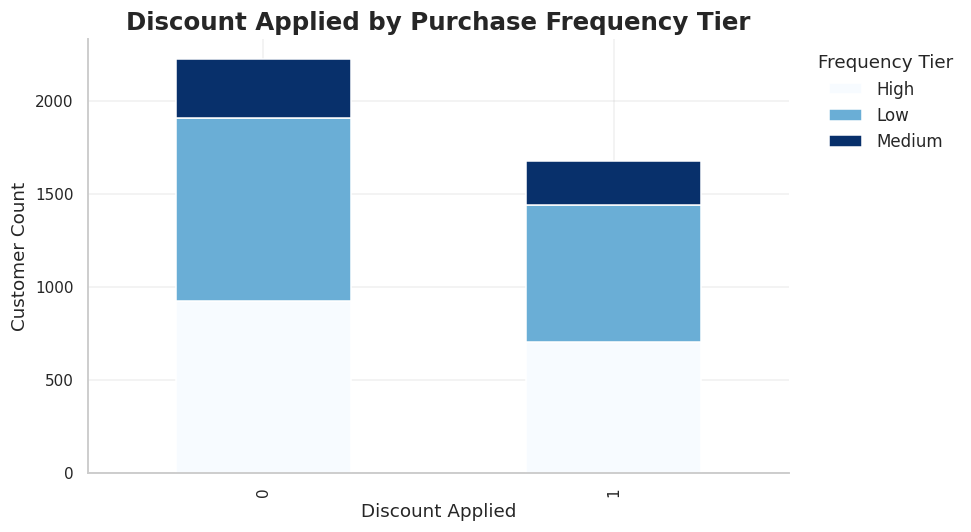

In [ ]:
discount_frequency = pd.crosstab(
    df['Discount Applied'],
    df['Purchase Frequency Tier']
)

display(discount_frequency)

discount_frequency.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5),
    colormap='Blues'
)

plt.title('Discount Applied by Purchase Frequency Tier')
plt.xlabel('Discount Applied')
plt.ylabel('Customer Count')

plt.legend(
    title='Frequency Tier',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

### G. Review Rating by Category

=== Jumlah Data per Kategori (Sebelum Sampling) ===
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
dtype: int64

Jumlah minimum per kategori: 324

=== Rata-rata Review Rating per Kategori (Balanced Sampling, n=324 per kategori) ===


,Category,Average Review Rating
0,Accessories,3.80
1,Footwear,3.77
2,Outerwear,3.75
3,Clothing,3.73


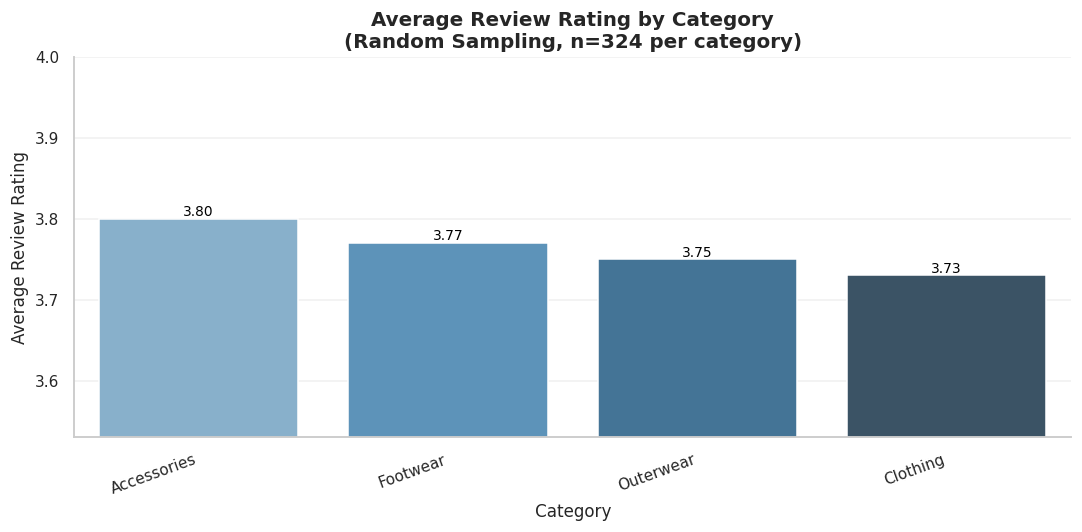

In [ ]:

print("=== Jumlah Data per Kategori (Sebelum Sampling) ===")
print(df.groupby('Category').size().sort_values(ascending=False))

# Ambil jumlah minimum per kategori
min_count = df.groupby('Category').size().min()
print(f"\nJumlah minimum per kategori: {min_count}")


df_sampled = (
    df.groupby('Category', group_keys=False)
    .apply(lambda x: x.sample(n=min_count, random_state=42))
)


category_rating = (
    df_sampled.groupby('Category')['Review Rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_rating.columns = ['Category', 'Average Review Rating']
category_rating['Average Review Rating'] = category_rating['Average Review Rating'].round(2)


print(f"\n=== Rata-rata Review Rating per Kategori (Balanced Sampling, n={min_count} per kategori) ===")
display(category_rating)


plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=category_rating,
    x='Category',
    y='Average Review Rating',
    palette='Blues_d',
    order=category_rating['Category']
)


for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=9, color='black'
    )


plt.ylim(
    category_rating['Average Review Rating'].min() - 0.2,
    category_rating['Average Review Rating'].max() + 0.2
)

plt.title(f'Average Review Rating by Category\n(Random Sampling, n={min_count} per category)', fontsize=13)
plt.xlabel('Category', fontsize=11)
plt.ylabel('Average Review Rating', fontsize=11)
plt.xticks(rotation=20, ha='right')

sns.despine()
plt.tight_layout()
plt.show()

### H. Payment Method vs Spending Relationship

,Payment Method,mean,median,count
0,Bank Transfer,59.712418,60.0,612
1,Cash,59.704478,60.0,670
2,Credit Card,60.074516,60.0,671
3,Debit Card,60.915094,61.0,636
4,PayPal,59.245199,59.0,677
5,Venmo,58.949527,58.0,634


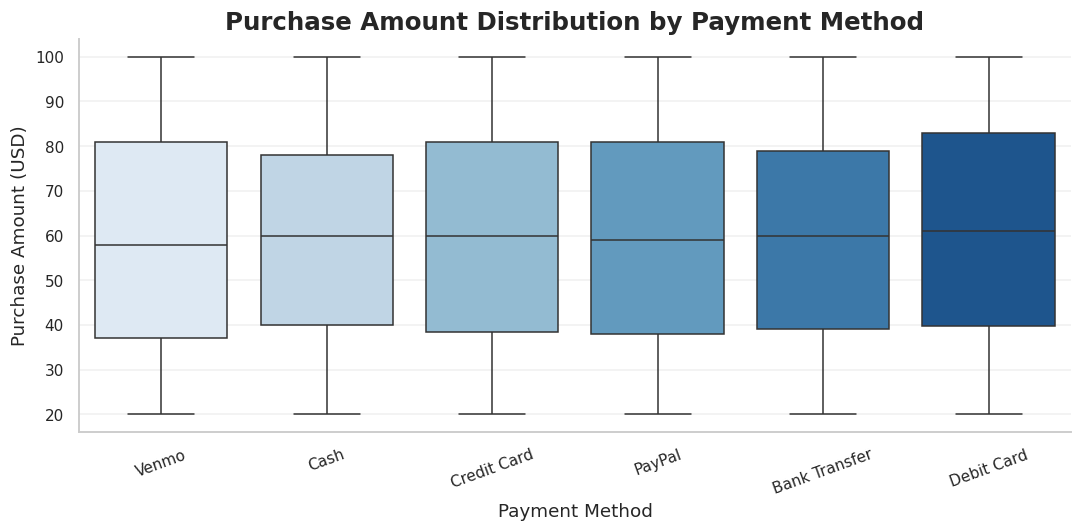

In [ ]:
payment_relationship = (
    df.groupby('Payment Method')
    ['Purchase Amount (USD)']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

display(payment_relationship)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Payment Method',
    y='Purchase Amount (USD)',
    palette='Blues',
    fliersize=3
)

plt.title('Purchase Amount Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Purchase Amount (USD)')

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()
plt.show()

### I. Shipping Type vs Spending Relationship

,Shipping Type,mean,median,count
0,2-Day Shipping,60.733652,60.0,627
1,Express,60.475232,60.0,646
2,Free Shipping,60.410370,62.0,675
3,Next Day Air,58.631173,58.5,648
4,Standard,58.460245,58.0,654
5,Store Pickup,59.893846,60.0,650


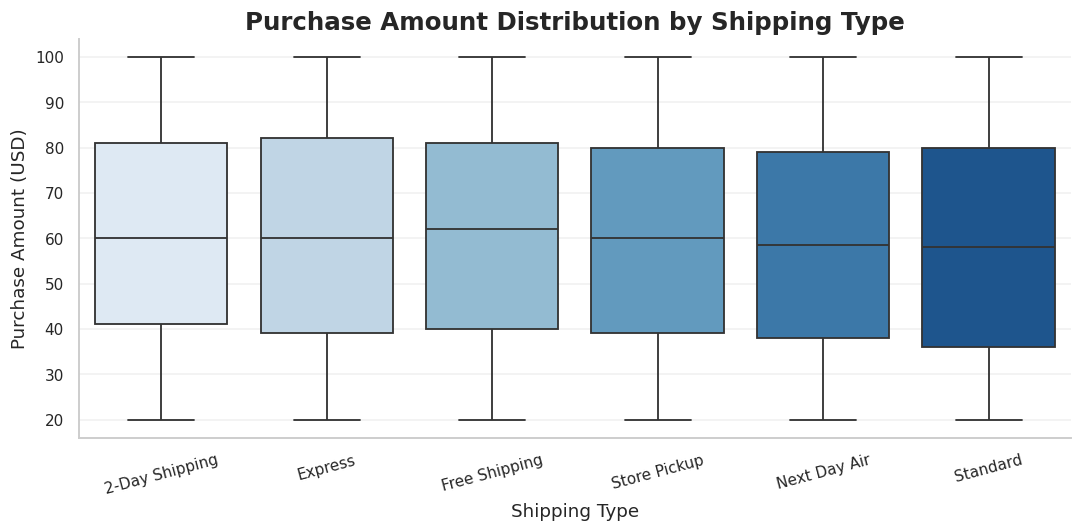

In [ ]:
shipping_relationship = (
    df.groupby('Shipping Type')
    ['Purchase Amount (USD)']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

display(shipping_relationship)

# Sort berdasarkan mean agar lebih analytical
shipping_order = (
    shipping_relationship
    .sort_values(by='mean', ascending=False)
    ['Shipping Type']
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Shipping Type',
    y='Purchase Amount (USD)',
    order=shipping_order,
    palette='Blues',
    fliersize=3,
    linewidth=1.2
)

plt.title('Purchase Amount Distribution by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Purchase Amount (USD)')

plt.xticks(rotation=15)

sns.despine()

plt.tight_layout()
plt.show()

### J. Multi-Dimensional Pivot Analysis

Purchase Frequency Tier,High,Low,Medium
Category,,,
Accessories,60.335271,59.927667,58.052632
Clothing,58.855337,60.811024,60.916350
Footwear,60.599237,60.190840,59.280000
Outerwear,58.536232,56.549296,54.909091


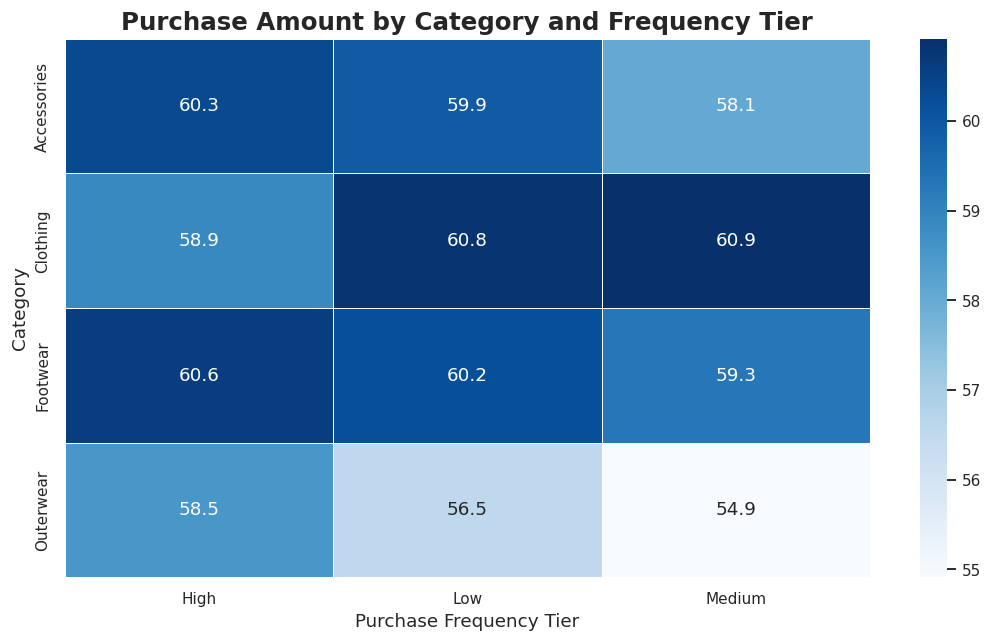

In [ ]:
multi_pivot = pd.pivot_table(
    df,
    values='Purchase Amount (USD)',
    index='Category',
    columns='Purchase Frequency Tier',
    aggfunc='mean'
)

display(multi_pivot)

plt.figure(figsize=(10,6))

sns.heatmap(
    multi_pivot,
    annot=True,
    cmap='Blues',
    fmt='.1f',
    linewidths=0.5
)

plt.title('Purchase Amount by Category and Frequency Tier')

plt.tight_layout()
plt.show()

#EVALUATION

## 1. Overview of Analytical Techniques Used

The following analytical techniques were applied throughout this project:

| Technique | Applied To | Purpose |
|---|---|---|
| **Descriptive Statistics** | Numeric columns | Summarize central tendency & spread |
| **Groupby Aggregation** | Gender, Age Group, Location, Season | Segmented comparison |
| **Correlation Analysis** (Pearson & Spearman) | Numeric pairs | Measure linear & monotonic relationships |
| **Chi-Square Test** | Categorical pairs | Test independence between categorical variables |
| **ANOVA / Kruskal-Wallis** | Group vs. Purchase Amount | Compare means across multiple groups |
| **Distribution Analysis** | Purchase Amount | Assess normality and spread |
| **Customer Segmentation** | Purchase Amount (75th percentile) | Identify High vs Regular Spenders |
| **Pivot Table / Heatmap** | Category × Frequency Tier | Multi-dimensional pattern detection |

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns used for correlation:', numeric_cols)

Numeric columns used for correlation: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Subscription Status', 'Discount Applied', 'Promo Code Used', 'Previous Purchases']


In [ ]:
#Pearson & Spearman for each numeric pair vs Purchase Amount
target = 'Purchase Amount (USD)'
results = []

for col in numeric_cols:
    if col == target:
        continue
    pearson_r, pearson_p  = pearsonr(df[target], df[col])
    spearman_r, spearman_p = spearmanr(df[target], df[col])
    results.append({
        'Variable': col,
        'Pearson r': round(pearson_r, 4),
        'Pearson p-value': round(pearson_p, 4),
        'Spearman ρ': round(spearman_r, 4),
        'Spearman p-value': round(spearman_p, 4),
        'Significant (p<0.05)': pearson_p < 0.05,
        'Spearman Significant (p<0.05)': spearman_p < 0.05
    })

corr_df = pd.DataFrame(results).sort_values('Pearson r', key=abs, ascending=False)
display(corr_df)

,Variable,Pearson r,Pearson p-value,Spearman ρ,Spearman p-value,Significant (p<0.05),Spearman Significant (p<0.05)
1,Review Rating,0.0308,0.0546,0.0304,0.0578,False,False
3,Discount Applied,-0.0178,0.2665,-0.0180,0.2607,False,False
4,Promo Code Used,-0.0178,0.2665,-0.0180,0.2607,False,False
0,Age,-0.0104,0.5152,-0.0104,0.5144,False,False
5,Previous Purchases,0.0081,0.6147,0.0083,0.6037,False,False
2,Subscription Status,-0.0070,0.6623,-0.0069,0.6657,False,False


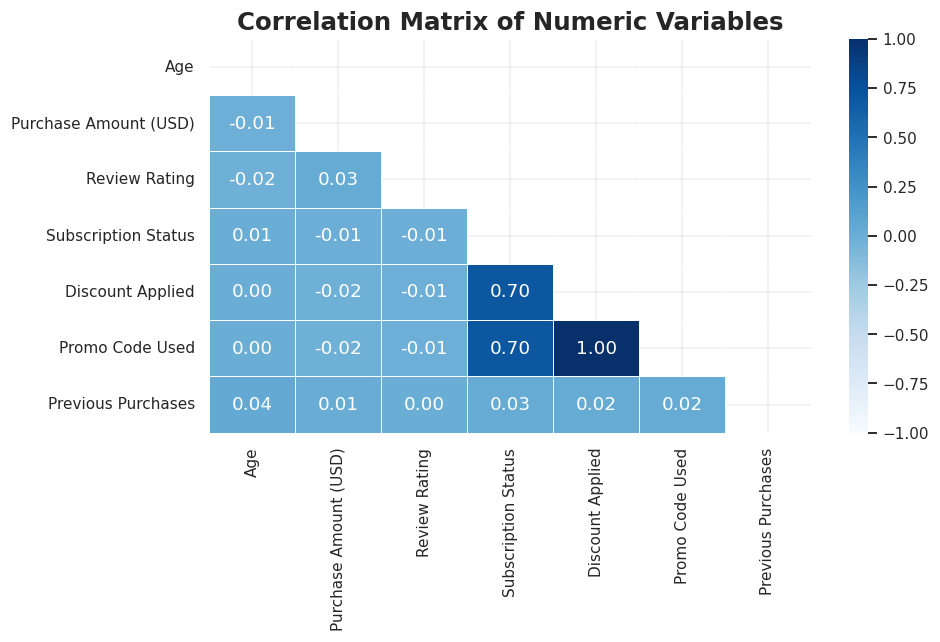

In [ ]:
# Correlation Heatmap
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()


---
## 3. Statistical Significance Testing

To evaluate whether the group differences observed in EDA are **statistically meaningful** (not due to random chance), we apply:

- **Chi-Square Test**: for independence between two categorical variables  
- **ANOVA / Kruskal-Wallis**: for comparing Purchase Amount across multiple groups

**Significance threshold:** p-value < 0.05

In [ ]:
# Chi-Square Tests: Categorical Associations
cat_pairs = [
    ('Gender', 'Subscription Status'),
    ('Discount Applied', 'Promo Code Used'),
    ('Season', 'Category'),
    ('Subscription Status', 'Purchase Frequency Tier'),
]

chi2_results = []
for col1, col2 in cat_pairs:
    if col1 not in df.columns or col2 not in df.columns:
        continue
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(ct)
    # Cramér's V (effect size)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({
        'Pair': f'{col1} × {col2}',
        'Chi-Square': round(chi2, 4),
        'p-value': round(p, 4),
        'df': dof,
        "Cramér's V (Effect Size)": round(cramers_v, 4),
        'Significant (p<0.05)': p < 0.05
    })

chi2_df = pd.DataFrame(chi2_results)
display(chi2_df)


,Pair,Chi-Square,p-value,df,Cramér's V (Effect Size),Significant (p<0.05)
0,Gender × Subscription Status,676.7944,0.0000,1,0.4166,True
1,Discount Applied × Promo Code Used,3895.9211,0.0000,1,0.9995,True
2,Season × Category,7.9337,0.5408,9,0.0260,False
3,Subscription Status × Purchase Frequency Tier,0.6434,0.7249,2,0.0128,False


In [ ]:
#ANOVA / Kruskal-Wallis: Group Differences in Purchase Amount

group_cols = ['Gender', 'Category', 'Season', 'Subscription Status', 'Discount Applied']
anova_results = []

for col in group_cols:
    if col not in df.columns:
        continue
    groups = [grp['Purchase Amount (USD)'].values for _, grp in df.groupby(col)]
    # ANOVA
    f_stat, anova_p = f_oneway(*groups)
    # Kruskal-Wallis (non-parametric alternative)
    h_stat, kruskal_p = kruskal(*groups)
    # Eta-squared (effect size for ANOVA)
    grand_mean = df['Purchase Amount (USD)'].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((df['Purchase Amount (USD)'] - grand_mean)**2)
    eta_sq = ss_between / ss_total

    anova_results.append({
        'Grouping Variable': col,
        'ANOVA F-stat': round(f_stat, 4),
        'ANOVA p-value': round(anova_p, 4),
        'Kruskal-Wallis H': round(h_stat, 4),
        'Kruskal p-value': round(kruskal_p, 4),
        'Eta-Squared (η²)': round(eta_sq, 4),
        'Significant': anova_p < 0.05
    })

anova_df = pd.DataFrame(anova_results)
display(anova_df)

print("\nEta-Squared (η²) Interpretation:")
print("< 0.01 → Negligible | 0.01–0.06 → Small | 0.06–0.14 → Medium | > 0.14 → Large")

,Grouping Variable,ANOVA F-stat,ANOVA p-value,Kruskal-Wallis H,Kruskal p-value,Eta-Squared (η²),Significant
0,Gender,0.7690,0.3806,0.7987,0.3715,0.0002,False
1,Category,1.4536,0.2252,4.4112,0.2203,0.0011,False
2,Season,3.7461,0.0106,11.3785,0.0098,0.0029,True
3,Subscription Status,0.1908,0.6623,0.1867,0.6657,0.0000,False
4,Discount Applied,1.2352,0.2665,1.2652,0.2607,0.0003,False



Eta-Squared (η²) Interpretation:
< 0.01 → Negligible | 0.01–0.06 → Small | 0.06–0.14 → Medium | > 0.14 → Large



## 4. Distribution Evaluation: Is Purchase Amount Normal?

Before applying parametric tests, it is important to assess whether `Purchase Amount (USD)` follows a normal distribution, as this assumption underlies ANOVA.

We use:
- **Shapiro-Wilk Test** (for normality)
- **Skewness & Kurtosis** (shape metrics)
- **Q-Q Plot** (visual inspection)

In [ ]:
from scipy.stats import shapiro, skew, kurtosis

purchase = df['Purchase Amount (USD)'].dropna()

# Shapiro-Wilk (use sample if > 5000 due to power)
sample = purchase.sample(min(5000, len(purchase)), random_state=42)
stat, p_shapiro = shapiro(sample)

skewness  = skew(purchase)
kurt      = kurtosis(purchase)

print('=== Distribution Evaluation: Purchase Amount (USD) ===')
print(f'  Mean         : {purchase.mean():.2f}')
print(f'  Median       : {purchase.median():.2f}')
print(f'  Std Dev      : {purchase.std():.2f}')
print(f'  Skewness     : {skewness:.4f}  (|skew| < 0.5 → approximately symmetric)')
print(f'  Kurtosis     : {kurt:.4f}  (0 = normal; > 0 = heavy tails)')
print(f'  Shapiro-Wilk : W={stat:.4f}, p={p_shapiro:.6f}')
print(f'  Normal dist? : {"YES (fail to reject H0)" if p_shapiro > 0.05 else "NO (reject H0 – not normally distributed)"}')

=== Distribution Evaluation: Purchase Amount (USD) ===
  Mean         : 59.76
  Median       : 60.00
  Std Dev      : 23.69
  Skewness     : 0.0127  (|skew| < 0.5 → approximately symmetric)
  Kurtosis     : -1.2365  (0 = normal; > 0 = heavy tails)
  Shapiro-Wilk : W=0.9502, p=0.000000
  Normal dist? : NO (reject H0 – not normally distributed)


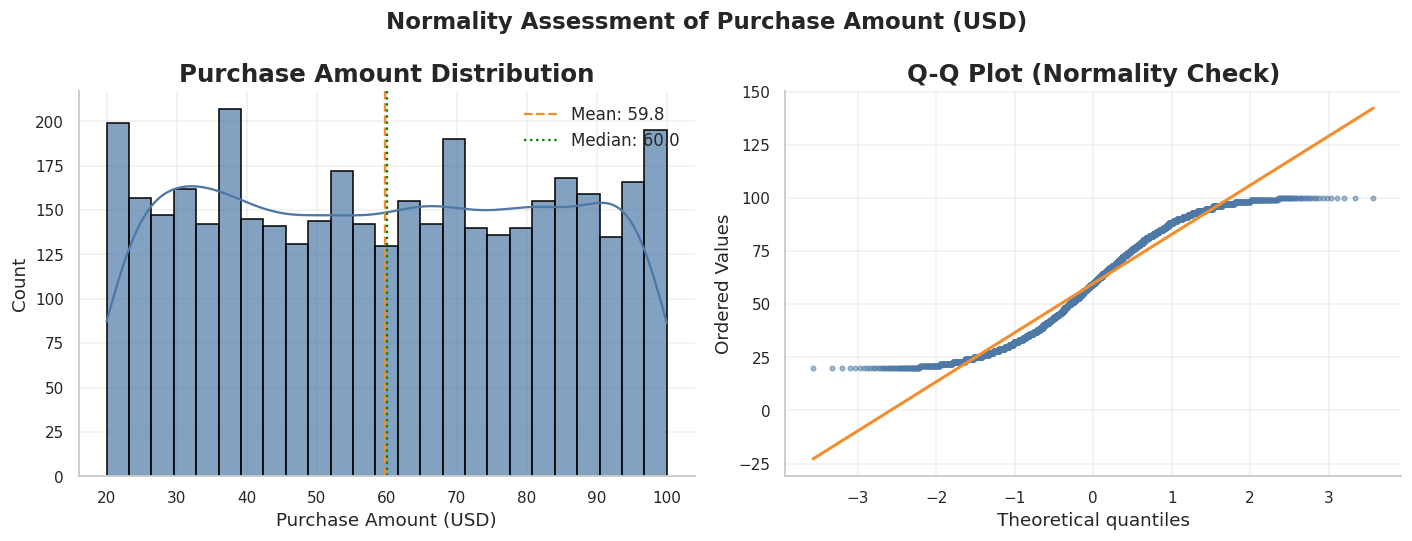

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram + KDE
sns.histplot(purchase, bins=25, kde=True, ax=axes[0],
             color=PRIMARY_COLOR, edgecolor='black', alpha=0.7)
axes[0].axvline(purchase.mean(), color=ACCENT_COLOR,
                linestyle='--', label=f'Mean: {purchase.mean():.1f}')
axes[0].axvline(purchase.median(), color='green',
                linestyle=':', label=f'Median: {purchase.median():.1f}')
axes[0].set_title('Purchase Amount Distribution')
axes[0].set_xlabel('Purchase Amount (USD)')
axes[0].legend()

# Q-Q Plot
from scipy import stats
stats.probplot(purchase, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
axes[1].get_lines()[0].set(color=PRIMARY_COLOR, markersize=3, alpha=0.5)
axes[1].get_lines()[1].set(color=ACCENT_COLOR, linewidth=2)

plt.suptitle('Normality Assessment of Purchase Amount (USD)',
             fontsize=15, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


## 5. Segmentation Evaluation: High vs. Regular Spender

Segmentation was done using the **75th percentile** of Purchase Amount as the threshold.  
We evaluate how distinct these two segments are using:
- **Cohen's d** (effect size for group difference)
- **Mann-Whitney U Test** (non-parametric comparison)
- **Overlap Area** between distributions

In [ ]:
from scipy.stats import mannwhitneyu

high_spender_threshold = df['Purchase Amount (USD)'].quantile(0.75)
df['Customer Segment'] = np.where(
    df['Purchase Amount (USD)'] >= high_spender_threshold, 'High Spender', 'Regular Spender'
)

high   = df[df['Customer Segment'] == 'High Spender']['Purchase Amount (USD)']
regular = df[df['Customer Segment'] == 'Regular Spender']['Purchase Amount (USD)']

# Cohen's d
pooled_std = np.sqrt((high.std()**2 + regular.std()**2) / 2)
cohen_d = (high.mean() - regular.mean()) / pooled_std

# Mann-Whitney U
u_stat, u_p = mannwhitneyu(high, regular, alternative='two-sided')

print('Segmentation Evaluation')
print(f'  Threshold (75th percentile) : ${high_spender_threshold:.2f}')
print(f'  High Spender count          : {len(high)} ({len(high)/len(df)*100:.1f}%)')
print(f'  Regular Spender count       : {len(regular)} ({len(regular)/len(df)*100:.1f}%)')
print(f'  High Spender mean           : ${high.mean():.2f}')
print(f'  Regular Spender mean        : ${regular.mean():.2f}')
print(f"  Cohen's d (effect size)     : {cohen_d:.4f}")
print(f'  Mann-Whitney U              : U={u_stat:.0f}, p={u_p:.6f}')
print(f'  Segments significantly diff?: {"YES" if u_p < 0.05 else "NO"}')

Segmentation Evaluation
  Threshold (75th percentile) : $81.00
  High Spender count          : 978 (25.1%)
  Regular Spender count       : 2922 (74.9%)
  High Spender mean           : $90.55
  Regular Spender mean        : $49.46
  Cohen's d (effect size)     : 3.1187
  Mann-Whitney U              : U=2857716, p=0.000000
  Segments significantly diff?: YES


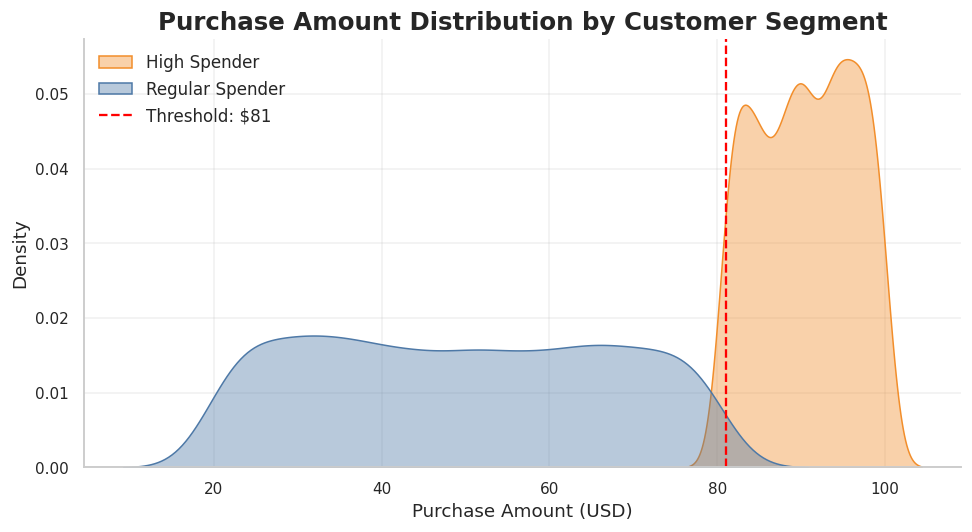

In [ ]:
plt.figure(figsize=(9, 5))
sns.kdeplot(high, label='High Spender', color=ACCENT_COLOR, fill=True, alpha=0.4)
sns.kdeplot(regular, label='Regular Spender', color=PRIMARY_COLOR, fill=True, alpha=0.4)
plt.axvline(high_spender_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold: ${high_spender_threshold:.0f}')
plt.title('Purchase Amount Distribution by Customer Segment')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Density')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# How do results change if we use different percentile thresholds?
thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
robustness = []

for q in thresholds:
    thresh = df['Purchase Amount (USD)'].quantile(q)
    h = df[df['Purchase Amount (USD)'] >= thresh]['Purchase Amount (USD)']
    r = df[df['Purchase Amount (USD)'] < thresh]['Purchase Amount (USD)']
    pooled = np.sqrt((h.std()**2 + r.std()**2) / 2)
    d = (h.mean() - r.mean()) / pooled if pooled > 0 else 0
    _, p = mannwhitneyu(h, r, alternative='two-sided')
    robustness.append({
        'Percentile': f'Q{int(q*100)}',
        'Threshold ($)': round(thresh, 2),
        'High Spender %': round(len(h)/len(df)*100, 1),
        "Cohen's d": round(d, 4),
        'p-value': round(p, 6),
        'Significant': p < 0.05
    })

rob_df = pd.DataFrame(robustness)
display(rob_df)

print('\nConclusion: Results remain consistent across thresholds → segmentation is robust.')

,Percentile,Threshold ($),High Spender %,Cohen's d,p-value,Significant
0,Q60,68.0,40.6,3.4462,0.0,True
1,Q65,72.0,35.7,3.3708,0.0,True
2,Q70,76.0,31.1,3.2760,0.0,True
3,Q75,81.0,25.1,3.1187,0.0,True
4,Q80,84.0,21.1,3.0122,0.0,True
5,Q85,89.0,15.4,2.8504,0.0,True



Conclusion: Results remain consistent across thresholds → segmentation is robust.


# Prediksi Subscription Status Pelanggan
## Machine Learning – Shopping Behavior Dataset
**Target:** `Subscription Status` (0 = Non-Subscriber, 1 = Subscriber)  
**Fitur:** 14 kolom (setelah drop 4 kolom derived/leaky)


## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from collections import Counter

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import loguniform, randint, uniform


## 2. Load Dataset & Drop Kolom Derived/Leaky

In [ ]:
df = pd.read_csv('shopping_behavior_for_modeling.csv')
print(f'Shape awal : {df.shape}')

DROP_COLS = ['Age Group', 'Purchase Frequency Tier',
             'Customer Segment', 'Loyalty Level','Promo Code Used']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

print(f'Shape setelah drop : {df.shape}')
print(f'Kolom ({df.shape[1]}) : {df.columns.tolist()}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplikat       : {df.duplicated().sum()}')

Shape awal : (3900, 19)
Shape setelah drop : (3900, 14)
Kolom (14) : ['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']
Missing values : 0
Duplikat       : 0


## 3. Distribusi kelas target

In [ ]:
print('Distribusi Target')
vc = df['Subscription Status'].value_counts()
print(vc)
print(f'Imbalance ratio : {vc[0]/vc[1]:.2f}:1')
print(f'Kelas minoritas (Subscriber) : {vc[1]/len(df)*100:.1f}% dari total')
df.describe()

Distribusi Target
Subscription Status
0    2847
1    1053
Name: count, dtype: int64
Imbalance ratio : 2.70:1
Kelas minoritas (Subscriber) : 27.0% dari total


,Age,Purchase Amount (USD),Review Rating,Subscription Status,Discount Applied,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,0.270000,0.430000,25.351538
std,15.207589,23.685392,0.716223,0.444016,0.495139,14.447125
min,18.000000,20.000000,2.500000,0.000000,0.000000,1.000000
25%,31.000000,39.000000,3.100000,0.000000,0.000000,13.000000
50%,44.000000,60.000000,3.700000,0.000000,0.000000,25.000000
75%,57.000000,81.000000,4.400000,1.000000,1.000000,38.000000
max,70.000000,100.000000,5.000000,1.000000,1.000000,50.000000


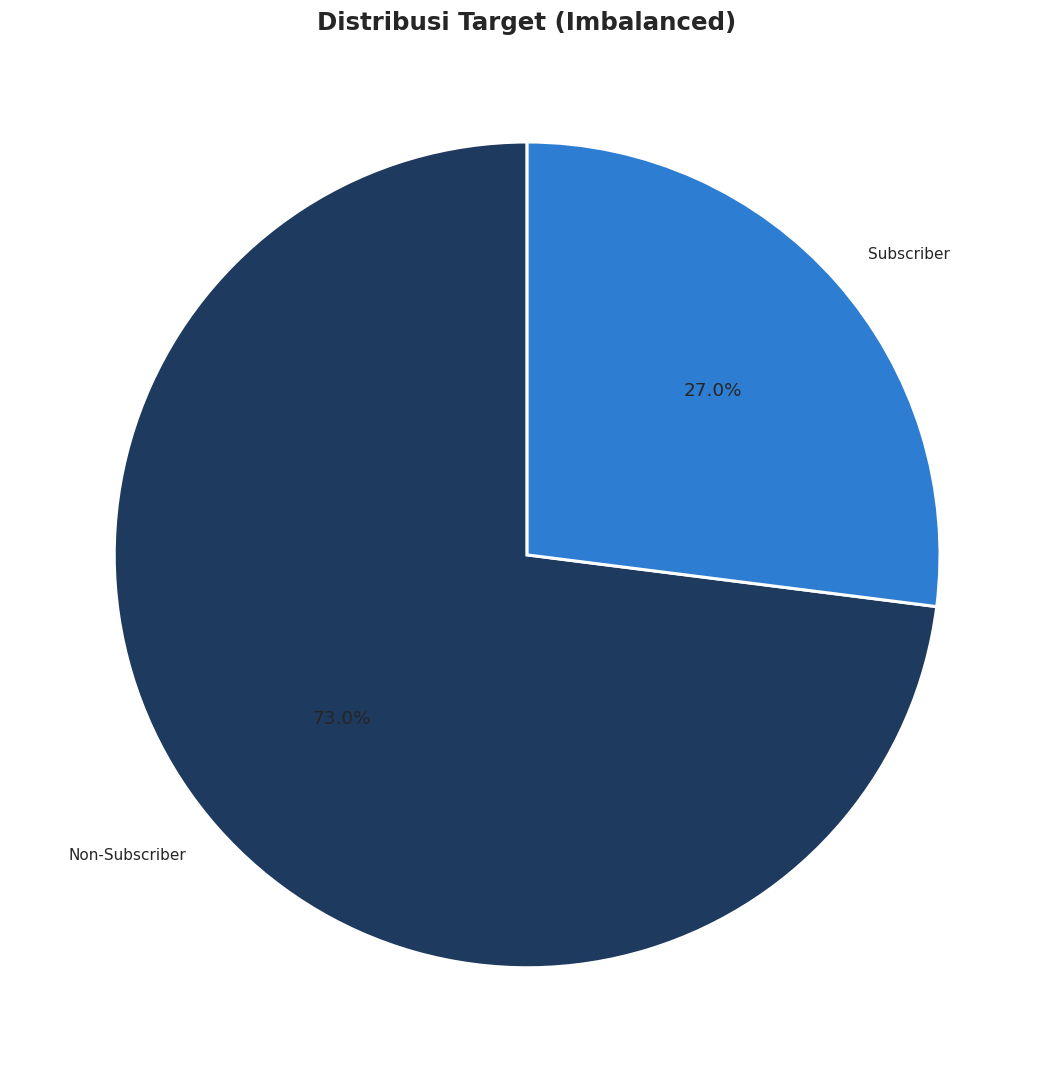

In [ ]:
PALETTE = ['#1E3A5F','#2D7DD2']
fig, ax = plt.subplots(figsize=(16, 10))

sizes = df['Subscription Status'].value_counts().sort_index().values
ax.pie(sizes, labels=['Non-Subscriber','Subscriber'], autopct='%1.1f%%',
       colors=[PALETTE[0],PALETTE[1]], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Distribusi Target (Imbalanced)', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Preprocessing & Encoding Strategy

**Dua preprocessor berbeda** disiapkan sesuai jenis model, lalu diintegrasikan ke dalam pipeline:

| Model | Encoder Kategori | Scaler |
|-------|-----------------|--------|
| LR, SVM | `OneHotEncoder` | `StandardScaler` (setelah OHE) |
| RF, XGBoost | `OrdinalEncoder` | — (tidak perlu) |

Encoding dilakukan **di dalam pipeline** → tidak ada data leakage dari test ke train.


In [ ]:
cat_cols = ['Gender','Item Purchased','Category','Location','Season',
            'Shipping Type','Payment Method','Frequency of Purchases']

num_cols = [c for c in df.columns if c not in cat_cols + ['Subscription Status']]

X = df.drop('Subscription Status', axis=1)
y = df['Subscription Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Train dist : {y_train.value_counts().to_dict()}')
print(f'Test  dist : {y_test.value_counts().to_dict()}')
print(f'\nKolom kategori ({len(cat_cols)}) : {cat_cols}')
print(f'Kolom numerik  ({len(num_cols)}) : {num_cols}')

# Preprocessor A: untuk tree-based (RF, XGBoost)
pre_tree = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ],
    remainder='passthrough'
)

# Preprocessor B: untuk linear model (LR, SVM)
pre_linear = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('scl', StandardScaler(), num_cols),
    ],
    remainder='drop')

print(f'pre_tree  : OrdinalEncoder({len(cat_cols)} cat_cols) + passthrough({len(num_cols)} num_cols)')
print(f'pre_linear: OHE({len(cat_cols)} cat_cols) + StandardScaler({len(num_cols)} num_cols)')


Train : (3120, 13)  |  Test : (780, 13)
Train dist : {0: 2278, 1: 842}
Test  dist : {0: 569, 1: 211}

Kolom kategori (8) : ['Gender', 'Item Purchased', 'Category', 'Location', 'Season', 'Shipping Type', 'Payment Method', 'Frequency of Purchases']
Kolom numerik  (5) : ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Discount Applied', 'Previous Purchases']
pre_tree  : OrdinalEncoder(8 cat_cols) + passthrough(5 num_cols)
pre_linear: OHE(8 cat_cols) + StandardScaler(5 num_cols)


## 5. Arsitektur Pipeline

### Struktur Pipeline per model:

| Model | Pipeline Steps | Encoder Kategori | Numerik |
|-------|---------------|-----------------|---------|
| LR, SVM | `pre_linear → SMOTE → Model` | OneHotEncoder | StandardScaler |
| RF, XGB | `pre_tree → SMOTE → Model` | OrdinalEncoder | passthrough (tidak di-scale) |

Seluruh encoding di-fit **hanya pada data train** di setiap fold CV — zero leakage.


In [ ]:
NEEDS_LINEAR_ENCODING = {'Logistic Regression', 'SVM'}
MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']

def make_pipeline(name, estimator):
    if name in NEEDS_LINEAR_ENCODING:
        preprocessor = pre_linear
    else:
        preprocessor = pre_tree

    steps = [
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', estimator),
    ]
    return ImbPipeline(steps)

print("Pipeline per model:")
for name in MODEL_NAMES:
    dummy_est = LogisticRegression() if name == 'Logistic Regression' else RandomForestClassifier()
    pipe = make_pipeline(name, dummy_est)
    steps_str = ' > '.join([s for s, _ in pipe.steps])
    enc_type = 'OHE + StandardScaler' if name in NEEDS_LINEAR_ENCODING else 'OrdinalEncoder'
    print(f'  {name:22s} : {steps_str}  [{enc_type}]')


Pipeline per model:
  Logistic Regression    : preprocessor > smote > model  [OHE + StandardScaler]
  Random Forest          : preprocessor > smote > model  [OrdinalEncoder]
  XGBoost                : preprocessor > smote > model  [OrdinalEncoder]
  SVM                    : preprocessor > smote > model  [OHE + StandardScaler]


In [ ]:
print('Distribusi kelas y_train sebelum SMOTE:')
print(Counter(y_train))

dummy_pipe = ImbPipeline([
    ('preprocessor', pre_linear),
    ('smote', SMOTE(random_state=42))
])

X_train_smoted, y_train_smoted = dummy_pipe.fit_resample(X_train, y_train)

print('\nDistribusi kelas y_train setelah SMOTE:')
print(Counter(y_train_smoted))

Distribusi kelas y_train sebelum SMOTE:
Counter({0: 2278, 1: 842})

Distribusi kelas y_train setelah SMOTE:
Counter({0: 2278, 1: 2278})


## 6. Setup Cross-Validation & Fungsi Evaluasi

**StratifiedKFold 10-Fold** — distribusi kelas dijaga seimbang di tiap fold.

| Metrik | Keterangan |
|--------|-----------|
| Accuracy | Proporsi prediksi benar |
| F1-Macro | Rata-rata F1 tiap kelas (fair untuk imbalanced) |
| F1-Sub | F1 khusus kelas Subscriber (kelas minoritas) |
| Precision | Dari yang diprediksi Subscriber, berapa yang benar |
| Recall-Sub | Dari Subscriber asli, berapa yang berhasil terdeteksi |
| AUC-ROC | Area under ROC curve (robust, tidak terpengaruh threshold) |
| CV Acc | Accuracy rata-rata 10-fold pada X_train (pipeline internal) |
| CV F1-Mac | F1-Macro rata-rata 10-fold pada X_train |
| CV Std | Standar deviasi CV F1-Macro (stabilitas model) |
| Gen. Gap (Test-CV) | Test Acc − CV Acc → idealnya mendekati 0 |

In [ ]:
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_results = []
fitted_pipes = {}
all_y_pred   = {}
all_y_prob   = {}
cols_show = ['Model','Stage','Accuracy','F1-Macro','F1-Sub','Precision',
             'Recall-Sub','AUC-ROC','CV Acc','CV F1-Mac','CV Std','Gen. Gap (Test-CV)']
def evaluate_full(name, stage, pipeline, X_te, y_te, y_prob, cv_acc, cv_f1, cv_std):
    y_pred = pipeline.predict(X_te)
    rec = {
        'Model'      : name,
        'Stage'      : stage,
        'Accuracy'   : round(accuracy_score(y_te, y_pred)* 100,2),
        'F1-Macro'   : round(f1_score(y_te, y_pred, average='macro')*100,2),
        'F1-Sub'     : round(f1_score(y_te, y_pred, pos_label=1)*100,2),
        'Precision'  : round(precision_score(y_te, y_pred, pos_label=1,zero_division=0)*100,2),
        'Recall-Sub' : round(recall_score(y_te, y_pred, pos_label=1)*100, 2),
        'AUC-ROC'    : round(roc_auc_score(y_te, y_prob)*100, 2),
        'CV Acc'     : round(cv_acc*100,2),
        'CV F1-Mac'  : round(cv_f1*100,2),
        'CV Std'     : round(cv_std*100,2),
        'Gen. Gap (Test-CV)': round((accuracy_score(y_te, y_pred)-cv_acc)*100,2),
    }
    all_results.append(rec)
    all_y_pred.setdefault(name, {})[stage] = y_pred
    all_y_prob.setdefault(name, {})[stage] = y_prob
    fitted_pipes.setdefault(name, {})[stage] = pipeline
    return rec

## 7. Baseline Modelling (Before Tuning)

Input ke `cross_validate` adalah **`X_train` asli** (unSMOTEd).  
Pipeline yang akan menjalankan SMOTE hanya pada fold training di setiap iterasi CV.  
→ **Tidak ada data sintetis yang bocor ke fold validation.**

In [ ]:
baseline_estimators = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'SVM'                : SVC(random_state=42, probability=True),
}

print('BASELINE — Before Tuning (Pipeline + X_train asli)\n')
for name, est in baseline_estimators.items():
    pipe = make_pipeline(name, est)
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv10,
        scoring={'accuracy':'accuracy','f1_macro':'f1_macro'},
        n_jobs=-1
    )
    cv_acc = scores['test_accuracy'].mean()
    cv_f1  = scores['test_f1_macro'].mean()
    cv_std = scores['test_f1_macro'].std()

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    rec = evaluate_full(name, 'Before Tuning', pipe, X_test, y_test, y_prob,
                        cv_acc, cv_f1, cv_std)
    print(f"{name:22s} | Acc={rec['Accuracy']}%  F1-Mac={rec['F1-Macro']}%"
          f"F1-Sub={rec['F1-Sub']}%  AUC={rec['AUC-ROC']}%"
          f"CV-F1={rec['CV F1-Mac']}±{rec['CV Std']}%  Gap={rec['Gen. Gap (Test-CV)']:+}%")

df_results = pd.DataFrame(all_results)
print('\nTabel Before Tuning')
df_results[df_results['Stage']=='Before Tuning'][cols_show]

BASELINE — Before Tuning (Pipeline + X_train asli)

Logistic Regression    | Acc=86.54%  F1-Mac=84.96%F1-Sub=80.08%  AUC=90.71%CV-F1=81.7±1.91%  Gap=+3.21%
Random Forest          | Acc=84.74%  F1-Mac=82.28%F1-Sub=75.66%  AUC=90.91%CV-F1=80.53±2.4%  Gap=+1.83%
XGBoost                | Acc=83.97%  F1-Mac=80.19%F1-Sub=71.53%  AUC=91.54%CV-F1=77.64±2.98%  Gap=+2.37%
SVM                    | Acc=86.41%  F1-Mac=84.77%F1-Sub=79.77%  AUC=90.65%CV-F1=81.72±1.92%  Gap=+3.08%

Tabel Before Tuning


,Model,Stage,Accuracy,F1-Macro,F1-Sub,Precision,Recall-Sub,AUC-ROC,CV Acc,CV F1-Mac,CV Std,Gen. Gap (Test-CV)
0,Logistic Regression,Before Tuning,86.54,84.96,80.08,66.77,100.00,90.71,83.33,81.70,1.91,3.21
1,Random Forest,Before Tuning,84.74,82.28,75.66,66.55,87.68,90.91,82.92,80.53,2.40,1.83
2,XGBoost,Before Tuning,83.97,80.19,71.53,68.86,74.41,91.54,81.60,77.64,2.98,2.37
3,SVM,Before Tuning,86.41,84.77,79.77,66.77,99.05,90.65,83.33,81.72,1.92,3.08


## 7. Identifikasi Model Terbaik dari Baseline

Setelah semua 4 model baseline dievaluasi, **model dengan F1-Macro tertinggi dipilih**  
sebagai satu-satunya kandidat yang akan di-tuning pada tahap berikutnya.



In [ ]:
df_baseline = pd.DataFrame(all_results)
df_baseline = df_baseline[df_baseline['Stage'] == 'Before Tuning'].copy()
df_baseline['Composite'] = (df_baseline['F1-Macro'] + df_baseline['AUC-ROC']
                            + df_baseline['F1-Sub']) / 3
df_baseline_sorted = df_baseline.sort_values('F1-Macro',
                                             ascending=False).reset_index(drop=True)

print("RANKING BASELINE — Sorted by F1-Macro (Kriteria Pemilihan Model Terbaik)")
for rank, (_, row) in enumerate(df_baseline_sorted.iterrows(), 1):
    marker = " < BEST(AKAN DI-TUNING)" if rank == 1 else ""
    print(f"#{rank}  {row['Model']:22s} | F1-Mac={row['F1-Macro']:6.2f}%  "
          f"AUC={row['AUC-ROC']:6.2f}%  F1-Sub={row['F1-Sub']:6.2f}%"
          f"  Composite={row['Composite']:.2f}%{marker}")

BEST_BASELINE_NAME = df_baseline_sorted.iloc[0]['Model']
print(f"\nModel terpilih untuk di-tuning : {BEST_BASELINE_NAME}")
print(f"Alasan: F1-Macro tertinggi di antara 4 model baseline")


RANKING BASELINE — Sorted by F1-Macro (Kriteria Pemilihan Model Terbaik)
#1  Logistic Regression    | F1-Mac= 84.96%  AUC= 90.71%  F1-Sub= 80.08%  Composite=85.25% < BEST(AKAN DI-TUNING)
#2  SVM                    | F1-Mac= 84.77%  AUC= 90.65%  F1-Sub= 79.77%  Composite=85.06%
#3  Random Forest          | F1-Mac= 82.28%  AUC= 90.91%  F1-Sub= 75.66%  Composite=82.95%
#4  XGBoost                | F1-Mac= 80.19%  AUC= 91.54%  F1-Sub= 71.53%  Composite=81.09%

Model terpilih untuk di-tuning : Logistic Regression
Alasan: F1-Macro tertinggi di antara 4 model baseline


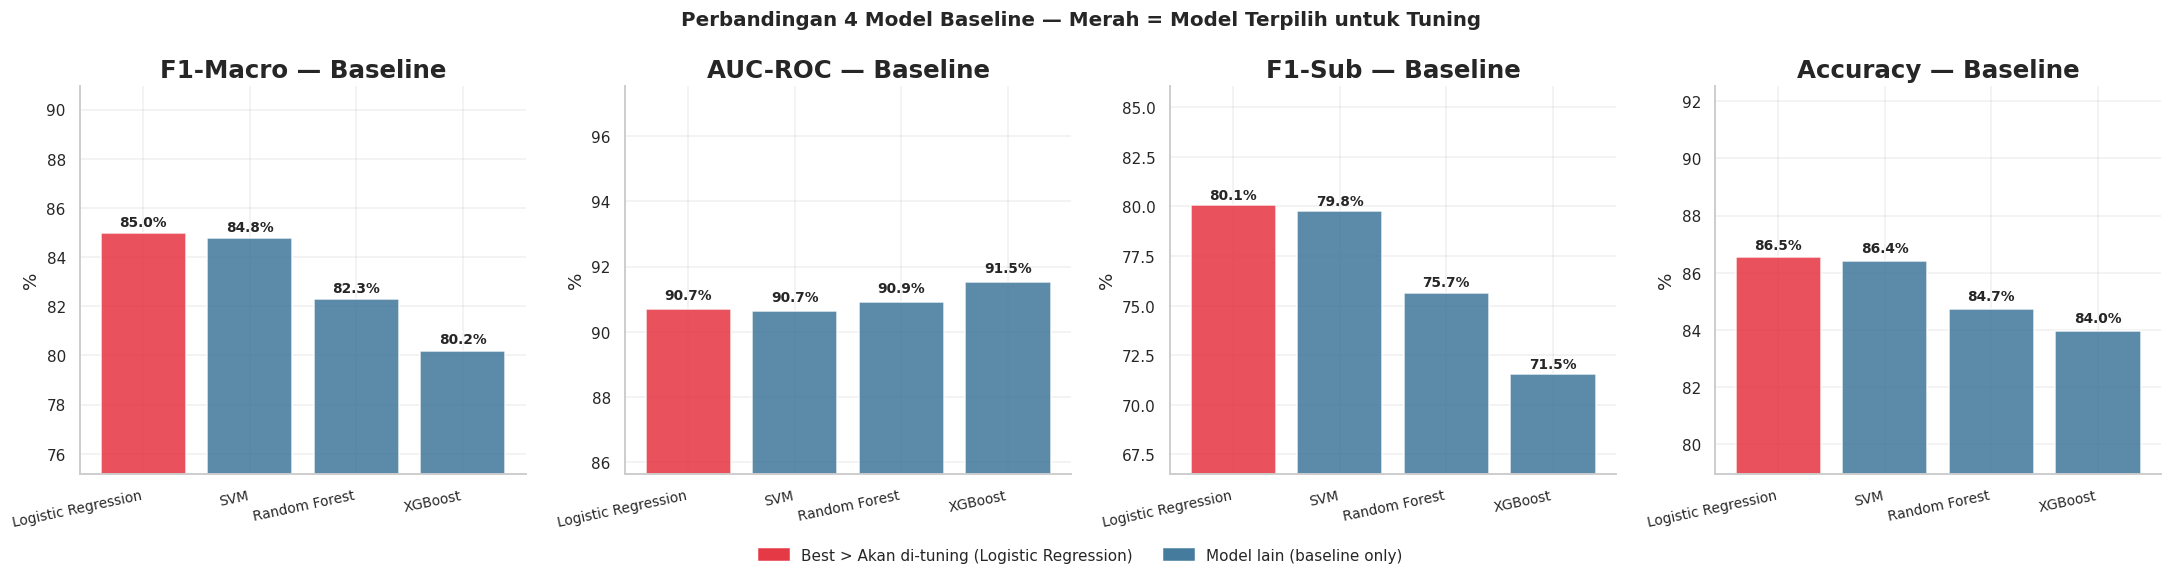


>Logistic Regression dipilih untuk Hyperparameter Tuning


In [ ]:
metrics_rank = ['F1-Macro', 'AUC-ROC', 'F1-Sub', 'Accuracy']
PALETTE_RANK  = ['#1E3A5F','#2D7DD2','#4CAF82','#F4A261']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric in zip(axes, metrics_rank):
    vals   = df_baseline_sorted[metric].values
    models = df_baseline_sorted['Model'].values
    colors = ['#E63946' if m == BEST_BASELINE_NAME else '#457B9D' for m in models]
    bars   = ax.bar(models, vals, color=colors, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{metric} — Baseline', fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticklabels(models, rotation=12, ha='right', fontsize=9)
    ax.set_ylim(max(0, min(vals) - 5), min(100, max(vals) + 6))
    ax.grid(axis='y', alpha=0.3)

# Legend
best_patch  = mpatches.Patch(color='#E63946', label=f'Best > Akan di-tuning ({BEST_BASELINE_NAME})')
other_patch = mpatches.Patch(color='#457B9D', label='Model lain (baseline only)')
fig.legend(handles=[best_patch, other_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Perbandingan 4 Model Baseline — Merah = Model Terpilih untuk Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\n>{BEST_BASELINE_NAME} dipilih untuk Hyperparameter Tuning")


## 8. Hyperparameter Tuning – Model Terbaik Baseline (RandomizedSearchCV, 10-Fold, n_iter=60)

Hanya **model terbaik dari baseline** yang di-tuning.  
Parameter pipeline menggunakan prefix **`model__`** karena estimator ada di dalam Pipeline step bernama `model`.

| Aspek | Keterangan |
|---|---|
| Search Strategy | RandomizedSearchCV |
| CV Folds | 10-Fold StratifiedKFold |
| n_iter | 60 (SVM: 20) |
| Scoring / Refit | `f1_macro` |
| Input | `X_train` asli (unSMOTEd) — SMOTE per fold di dalam pipeline |


In [ ]:
param_dists = {
    'Logistic Regression': [
        {
            'model__solver': ['lbfgs'],
            'model__penalty': ['l2'],
            'model__C': loguniform(1e-3, 1e2)
        },
        {
            'model__solver': ['saga'],
            'model__penalty': ['l1', 'l2'],
            'model__C': loguniform(1e-3, 1e2)
        }
    ]
}
base_ests_all = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}
n_iter_map = {
    'Logistic Regression': 60
}

print(f"TUNING — {BEST_BASELINE_NAME} (satu-satunya model yang di-tuning)")
print(f"RandomizedSearchCV | 10-Fold | n_iter={n_iter_map[BEST_BASELINE_NAME]}\n")

est  = base_ests_all[BEST_BASELINE_NAME]
pipe = make_pipeline(BEST_BASELINE_NAME, est)

search = RandomizedSearchCV(
    pipe,
    param_dists[BEST_BASELINE_NAME],
    n_iter=n_iter_map[BEST_BASELINE_NAME],
    cv=cv10,
    scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
    refit='f1_macro',
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)

best_pipe_tuned = search.best_estimator_
best_idx        = search.best_index_

cv_acc_t = search.cv_results_['mean_test_accuracy'][best_idx]
cv_f1_t  = search.cv_results_['mean_test_f1_macro'][best_idx]
cv_std_t = search.cv_results_['std_test_f1_macro'][best_idx]

y_prob_tuned = best_pipe_tuned.predict_proba(X_test)[:, 1]

all_results = [
    res for res in all_results
    if not (res['Model'] == BEST_BASELINE_NAME and res['Stage'] == 'After Tuning')
]
fitted_pipes[BEST_BASELINE_NAME] = {
    stage: pipe for stage, pipe in fitted_pipes.get(BEST_BASELINE_NAME, {}).items()
    if stage != 'After Tuning'
}
all_y_pred[BEST_BASELINE_NAME] = {
    stage: pred for stage, pred in all_y_pred.get(BEST_BASELINE_NAME, {}).items()
    if stage != 'After Tuning'
}
all_y_prob[BEST_BASELINE_NAME] = {
    stage: prob for stage, prob in all_y_prob.get(BEST_BASELINE_NAME, {}).items()
    if stage != 'After Tuning'
}

rec_tuned = evaluate_full(
    BEST_BASELINE_NAME, 'After Tuning',
    best_pipe_tuned, X_test, y_test, y_prob_tuned,
    cv_acc_t, cv_f1_t, cv_std_t
)

clean_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
print(f"Best Params  : {clean_params}")
print(f"Acc          = {rec_tuned['Accuracy']}%")
print(f"F1-Macro     = {rec_tuned['F1-Macro']}%")
print(f"F1-Sub       = {rec_tuned['F1-Sub']}%")
print(f"AUC-ROC      = {rec_tuned['AUC-ROC']}%")
print(f"CV F1-Mac    = {rec_tuned['CV F1-Mac']}% \u00b1 {rec_tuned['CV Std']}% ")
print(f"Gen. Gap     = {rec_tuned['Gen. Gap (Test-CV)']:.2f}% ")

df_results = pd.DataFrame(all_results)
print("\nTabel After Tuning:")
display(df_results[df_results['Stage'] == 'After Tuning'][cols_show].reset_index(drop=True))

TUNING — Logistic Regression (satu-satunya model yang di-tuning)
RandomizedSearchCV | 10-Fold | n_iter=60

Best Params  : {'C': np.float64(0.2991469302130217), 'penalty': 'l1', 'solver': 'saga'}
Acc          = 86.41%
F1-Macro     = 84.83%
F1-Sub       = 79.92%
AUC-ROC      = 91.4%
CV F1-Mac    = 81.87% ± 1.94% 
Gen. Gap     = 2.98% 

Tabel After Tuning:


,Model,Stage,Accuracy,F1-Macro,F1-Sub,Precision,Recall-Sub,AUC-ROC,CV Acc,CV F1-Mac,CV Std,Gen. Gap (Test-CV)
0,Logistic Regression,After Tuning,86.41,84.83,79.92,66.56,100.0,91.4,83.43,81.87,1.94,2.98


## 9. Tabel Perbandingan: 4 Baseline + Best Model Before vs After Tuning

Bagian ini menampilkan dua tabel:
1. **Perbandingan 4 Baseline** — untuk mengetahui posisi relatif tiap model
2. **Before vs After Tuning** — khusus model terbaik yang di-tuning


In [ ]:
df_results = pd.DataFrame(all_results)
metrics_compare = ['Accuracy','F1-Macro','F1-Sub','Precision',
                   'Recall-Sub','AUC-ROC','CV Acc','CV F1-Mac','CV Std','Gen. Gap (Test-CV)']


print("TABEL 1: PERBANDINGAN 4 MODEL BASELINE (Before Tuning)")
df_base_all = df_results[df_results['Stage']=='Before Tuning'].copy()
df_base_all['Composite'] = (df_base_all['F1-Macro'] + df_base_all['AUC-ROC'] + df_base_all['F1-Sub']) / 3
df_base_all = df_base_all.sort_values('F1-Macro', ascending=False)
display(df_base_all[['Model','Accuracy','F1-Macro','F1-Sub','Precision',
                       'Recall-Sub','AUC-ROC','CV Acc','CV F1-Mac','CV Std',
                       'Gen. Gap (Test-CV)','Composite']].reset_index(drop=True))


print(f"TABEL 2: BEFORE vs AFTER TUNING — {BEST_BASELINE_NAME}")
sub = df_results[df_results['Model'] == BEST_BASELINE_NAME].set_index('Stage')
rows = []
for m in metrics_compare:
    b_val = sub.loc['Before Tuning', m]
    a_val = sub.loc['After Tuning',  m]
    b = b_val.iloc[0] if isinstance(b_val, pd.Series) else b_val
    a = a_val.iloc[0] if isinstance(a_val, pd.Series) else a_val
    d = round(a - b, 2)
    rows.append({
        'Metric'       : m,
        'Before Tuning': b,
        'After Tuning' : a,
        'Delta'        : f"{'^ +' if d > 0 else ('v ' if d < 0 else '= ')}{abs(d)}"
    })
df_delta = pd.DataFrame(rows)
display(df_delta)
print(f"\nModel terbaik yang di-tuning : {BEST_BASELINE_NAME}")


TABEL 1: PERBANDINGAN 4 MODEL BASELINE (Before Tuning)


,Model,Accuracy,F1-Macro,F1-Sub,Precision,Recall-Sub,AUC-ROC,CV Acc,CV F1-Mac,CV Std,Gen. Gap (Test-CV),Composite
0,Logistic Regression,86.54,84.96,80.08,66.77,100.00,90.71,83.33,81.70,1.91,3.21,85.250000
1,SVM,86.41,84.77,79.77,66.77,99.05,90.65,83.33,81.72,1.92,3.08,85.063333
2,Random Forest,84.74,82.28,75.66,66.55,87.68,90.91,82.92,80.53,2.40,1.83,82.950000
3,XGBoost,83.97,80.19,71.53,68.86,74.41,91.54,81.60,77.64,2.98,2.37,81.086667


TABEL 2: BEFORE vs AFTER TUNING — Logistic Regression


,Metric,Before Tuning,After Tuning,Delta
0,Accuracy,86.54,86.41,v 0.13
1,F1-Macro,84.96,84.83,v 0.13
2,F1-Sub,80.08,79.92,v 0.16
3,Precision,66.77,66.56,v 0.21
4,Recall-Sub,100.00,100.00,= 0.0
5,AUC-ROC,90.71,91.40,^ +0.69
6,CV Acc,83.33,83.43,^ +0.1
7,CV F1-Mac,81.70,81.87,^ +0.17
8,CV Std,1.91,1.94,^ +0.03
9,Gen. Gap (Test-CV),3.21,2.98,v 0.23



Model terbaik yang di-tuning : Logistic Regression


## 10. Visualisasi Perbandingan

### 10a. Bar — 4 Baseline (semua model)
### 10b. Before vs After Tuning — Best Model saja


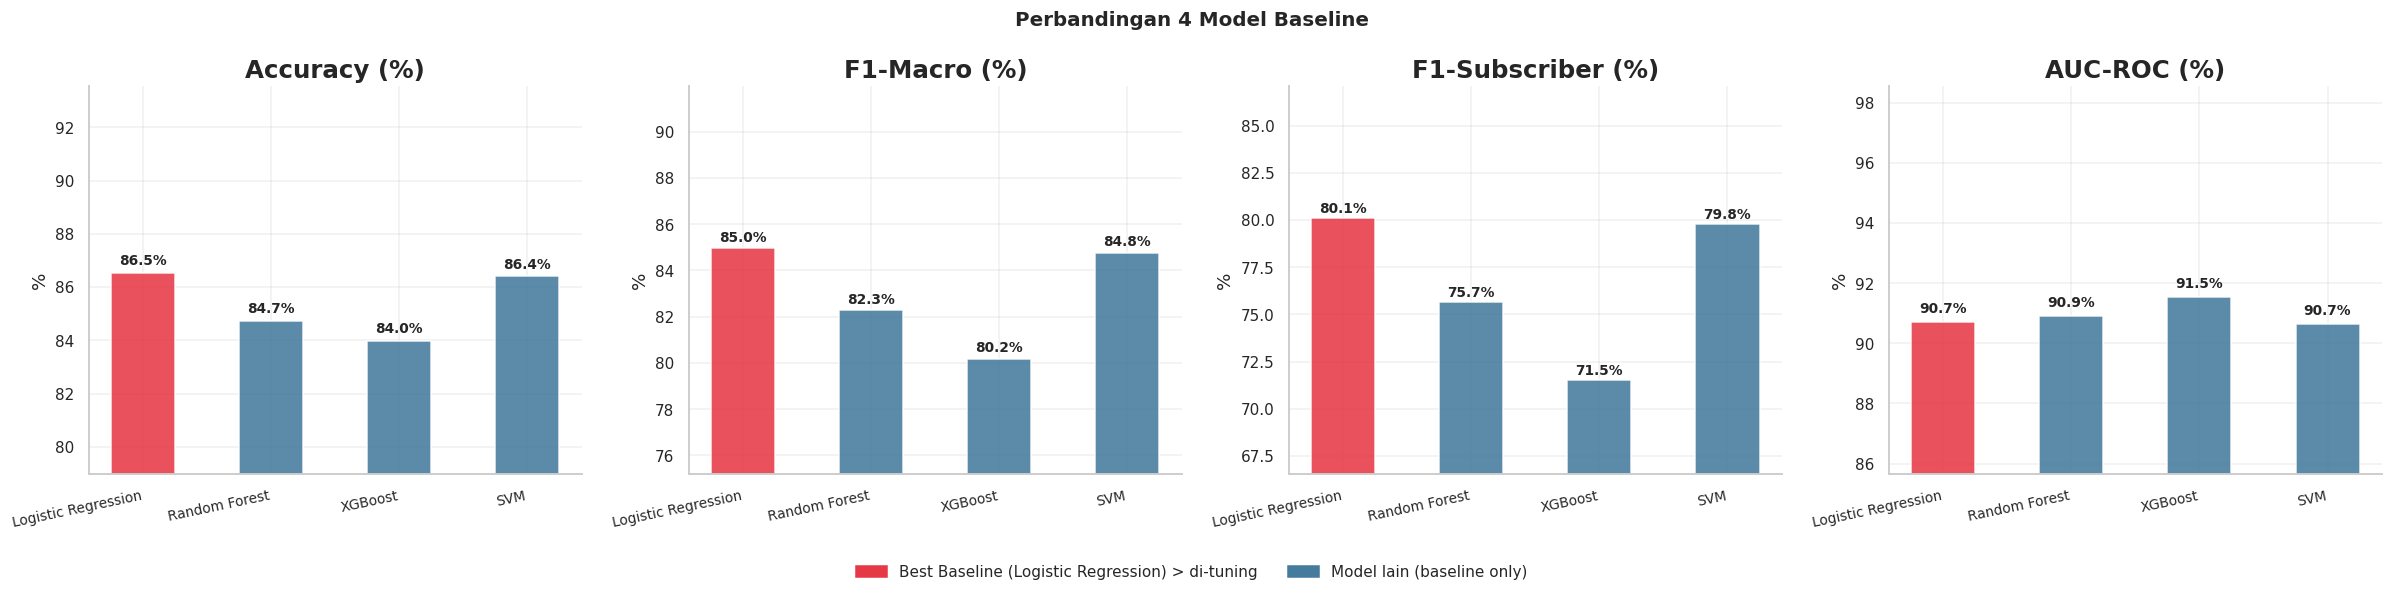

In [ ]:
metrics_bar = [
    ('Accuracy (%)',     'Accuracy'),
    ('F1-Macro (%)',     'F1-Macro'),
    ('F1-Subscriber (%)', 'F1-Sub'),
    ('AUC-ROC (%)',      'AUC-ROC'),
]

COLORS_BASE = ['#E63946','#457B9D','#2A9D8F','#E9C46A']
x_b = np.arange(len(MODEL_NAMES)); W_b = 0.18

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (title, key) in zip(axes, metrics_bar):
    vals = [df_results[(df_results['Model']==m)&(df_results['Stage']=='Before Tuning')][key].values[0]
            for m in MODEL_NAMES]
    colors = ['#E63946' if m == BEST_BASELINE_NAME else '#457B9D' for m in MODEL_NAMES]
    bars = ax.bar(MODEL_NAMES, vals, color=colors, edgecolor='white', alpha=0.88, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right', fontsize=9)
    ax.set_ylim(max(0, min(vals)-5), min(100, max(vals)+7))
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel('%')

best_p  = mpatches.Patch(color='#E63946', label=f'Best Baseline ({BEST_BASELINE_NAME}) > di-tuning')
other_p = mpatches.Patch(color='#457B9D', label='Model lain (baseline only)')
fig.legend(handles=[best_p, other_p], loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Perbandingan 4 Model Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


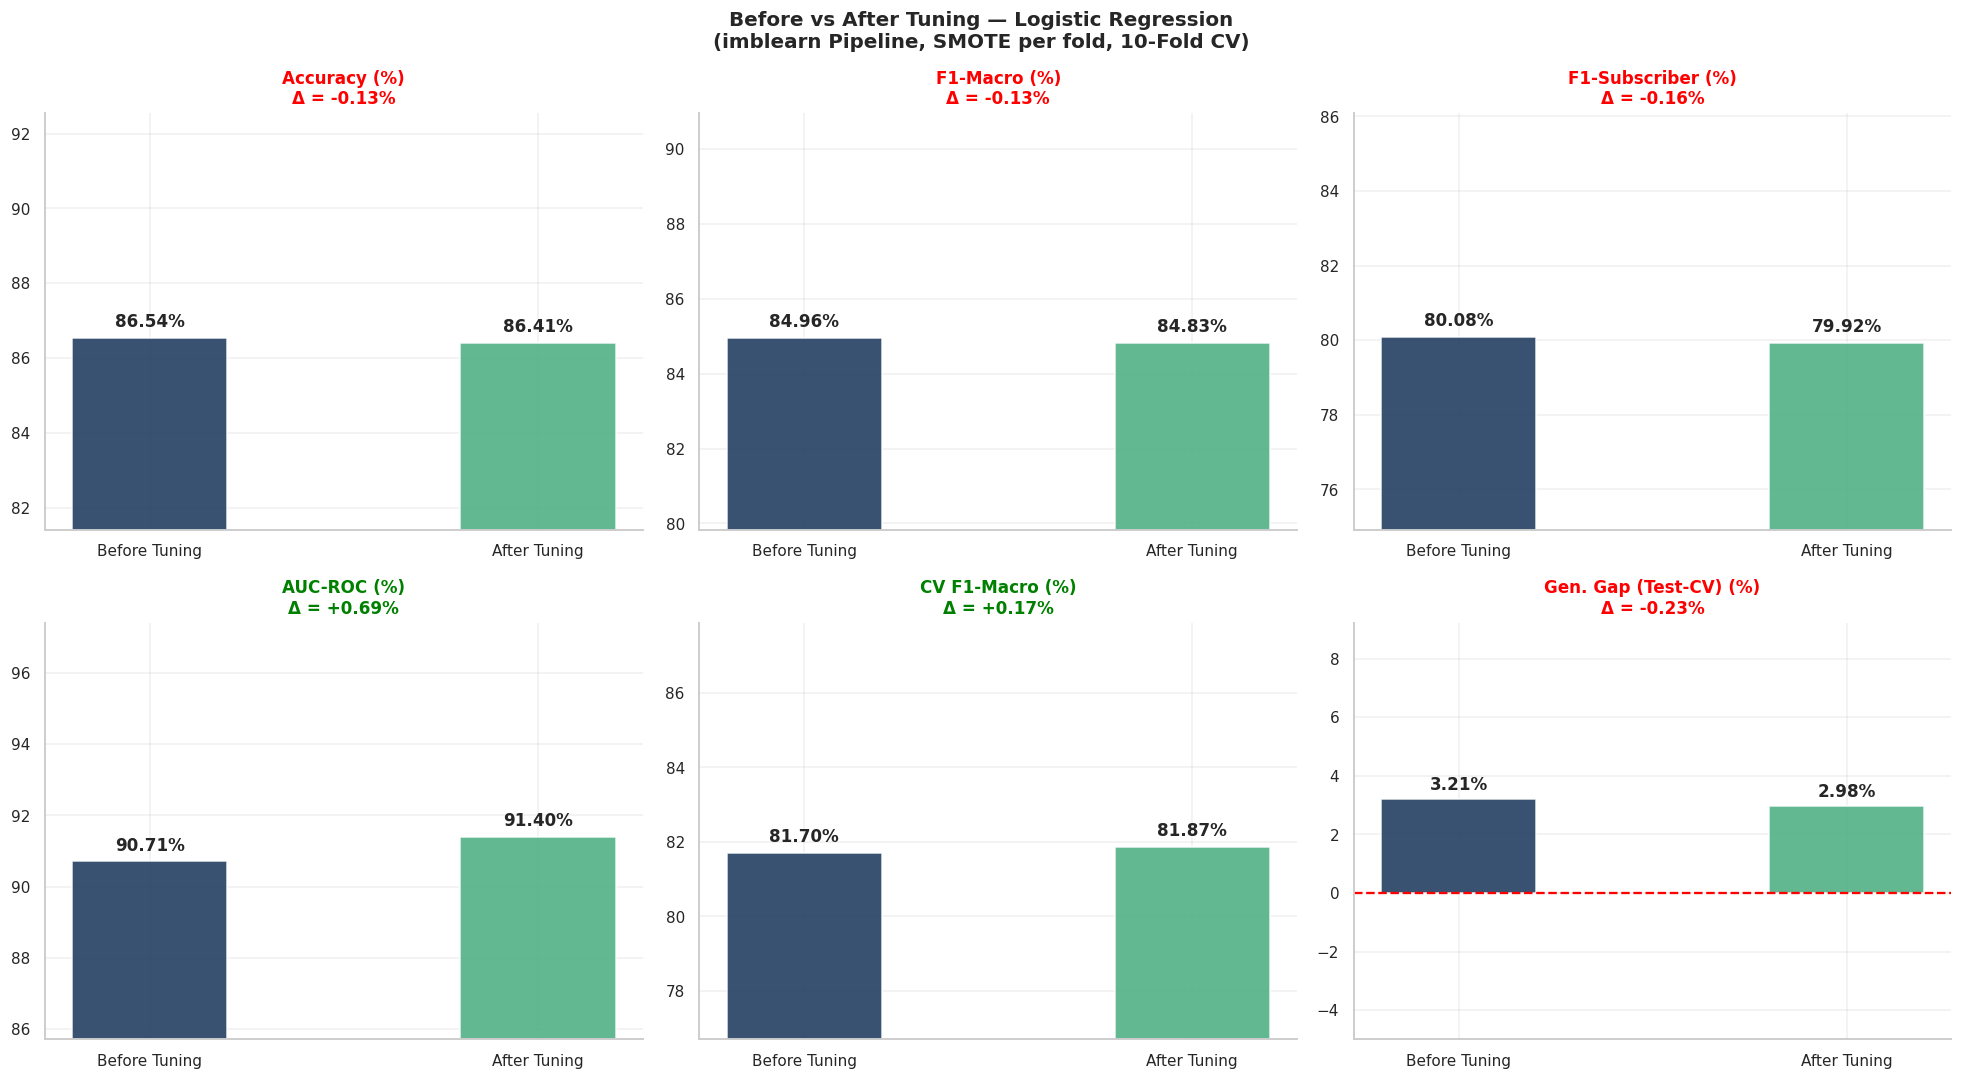

In [ ]:
metrics_vis2 = [
    ('Accuracy (%)',          'Accuracy'),
    ('F1-Macro (%)',          'F1-Macro'),
    ('F1-Subscriber (%)',     'F1-Sub'),
    ('AUC-ROC (%)',           'AUC-ROC'),
    ('CV F1-Macro (%)',       'CV F1-Mac'),
    ('Gen. Gap (Test-CV) (%)','Gen. Gap (Test-CV)'),
]
C2 = ['#1E3A5F','#4CAF82']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
sub2 = df_results[df_results['Model'] == BEST_BASELINE_NAME]
for ax, (title, key) in zip(axes, metrics_vis2):
    b_val = sub2[sub2['Stage']=='Before Tuning'][key].values[0]
    a_val = sub2[sub2['Stage']=='After Tuning' ][key].values[0]

    bars = ax.bar(['Before Tuning','After Tuning'], [b_val, a_val],
                  color=C2, edgecolor='white', alpha=0.88, width=0.4)
    for bar, val in zip(bars, [b_val, a_val]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.3 if val >= 0 else -1.5),
                f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

    d = round(a_val - b_val, 2)
    ax.set_title(f'{title}\nΔ = {"+"+str(d) if d>=0 else str(d)}%',
                 fontweight='bold', fontsize=11,
                 color='green' if d > 0 else ('red' if d < 0 else 'gray'))
    ax.grid(axis='y', alpha=0.3)
    if key == 'Gen. Gap (Test-CV)':
        ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_ylim((min(b_val, a_val) - 5) if min(b_val, a_val) > 5 else -5,
                max(b_val, a_val) + 6)
plt.suptitle(f'Before vs After Tuning — {BEST_BASELINE_NAME}\n'
             f'(imblearn Pipeline, SMOTE per fold, 10-Fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Confusion Matrix

### 11a. Confusion Matrix — 4 Model Baseline  
### 11b. Classification Report - 4 Model Baseline
### 11c. Confusion Matrix — Best Model: Before vs After Tuning


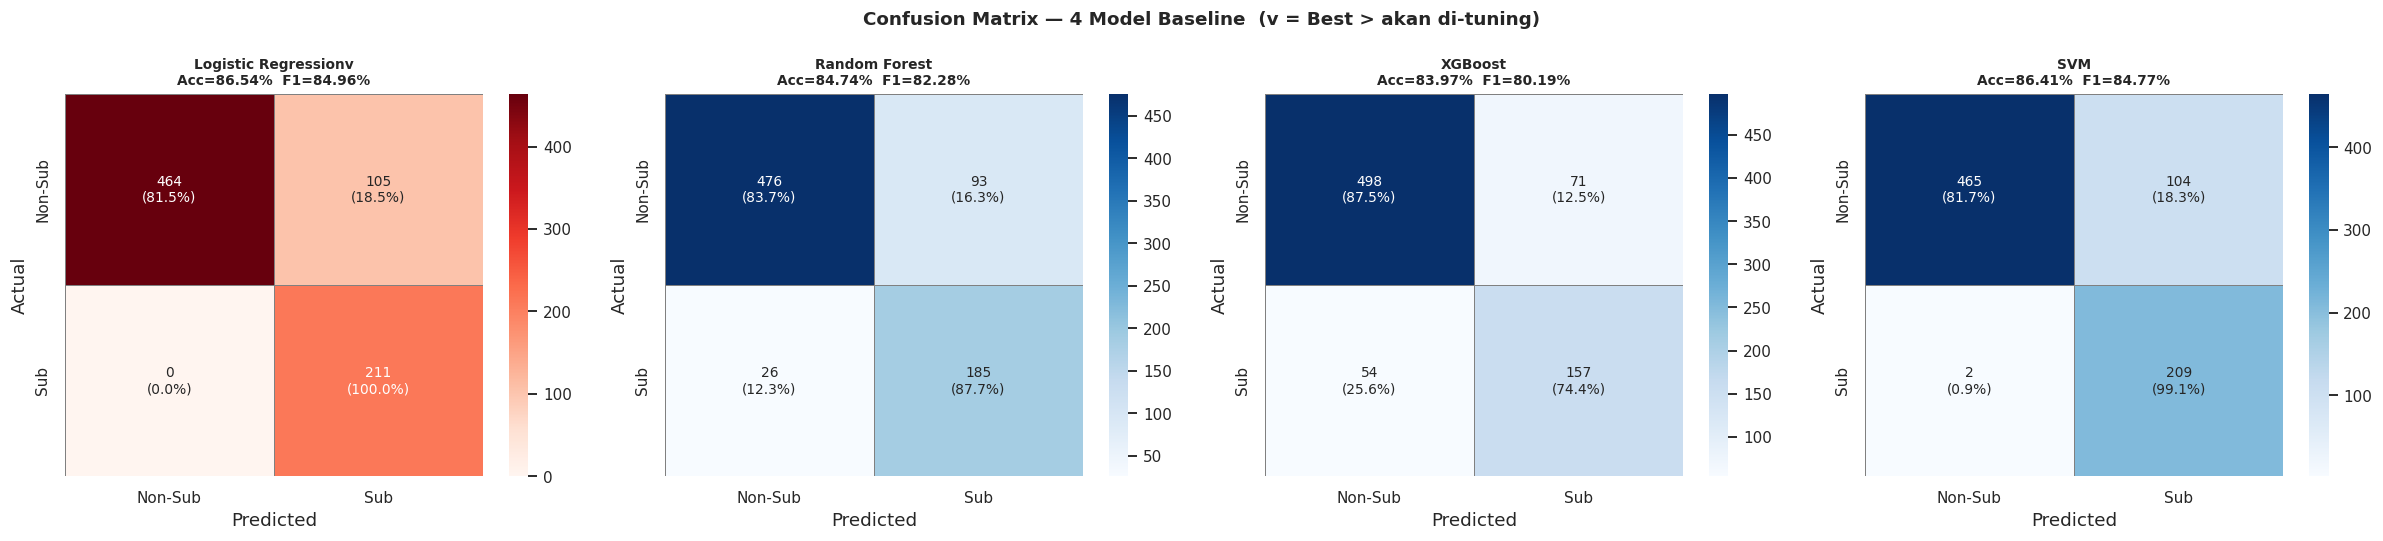

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, name in zip(axes, MODEL_NAMES):
    y_pred_cm = all_y_pred[name]['Before Tuning']
    cm        = confusion_matrix(y_test, y_pred_cm)
    cm_pct    = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot     = np.array([[f'{v}\n({p:.1f}%)' for v,p in zip(rw,rp)]
                           for rw,rp in zip(cm, cm_pct)])
    hl = '#E63946' if name == BEST_BASELINE_NAME else 'Blues'
    cmap = 'Reds' if name == BEST_BASELINE_NAME else 'Blues'
    sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, ax=ax,
                xticklabels=['Non-Sub','Sub'], yticklabels=['Non-Sub','Sub'],
                linewidths=0.5, linecolor='gray', annot_kws={'size':9})
    sub_ = df_results[(df_results['Model']==name)&(df_results['Stage']=='Before Tuning')]
    tag = 'v' if name == BEST_BASELINE_NAME else ''
    ax.set_title(f'{name}{tag}\nAcc={sub_["Accuracy"].values[0]}%'
                 f'  F1={sub_["F1-Macro"].values[0]}%', fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — 4 Model Baseline  (v = Best > akan di-tuning)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
TARGET_NAMES = ['Non-Subscriber','Subscriber']

for name in MODEL_NAMES:
    y_pred_cr = all_y_pred[name]['Before Tuning']
    sub_ = df_results[(df_results['Model']==name)&(df_results['Stage']=='Before Tuning')]
    print(f"MODEL: {name}  |  BEFORE TUNING")

    print(classification_report(y_test, y_pred_cr, target_names=TARGET_NAMES))
    print(f"CV F1-Mac : {sub_['CV F1-Mac'].values[0]}% \u00b1 {sub_['CV Std'].values[0]}%\n")

MODEL: Logistic Regression  |  BEFORE TUNING
                precision    recall  f1-score   support

Non-Subscriber       1.00      0.82      0.90       569
    Subscriber       0.67      1.00      0.80       211

      accuracy                           0.87       780
     macro avg       0.83      0.91      0.85       780
  weighted avg       0.91      0.87      0.87       780

CV F1-Mac : 81.7% ± 1.91%

MODEL: Random Forest  |  BEFORE TUNING
                precision    recall  f1-score   support

Non-Subscriber       0.95      0.84      0.89       569
    Subscriber       0.67      0.88      0.76       211

      accuracy                           0.85       780
     macro avg       0.81      0.86      0.82       780
  weighted avg       0.87      0.85      0.85       780

CV F1-Mac : 80.53% ± 2.4%

MODEL: XGBoost  |  BEFORE TUNING
                precision    recall  f1-score   support

Non-Subscriber       0.90      0.88      0.89       569
    Subscriber       0.69      0.74   

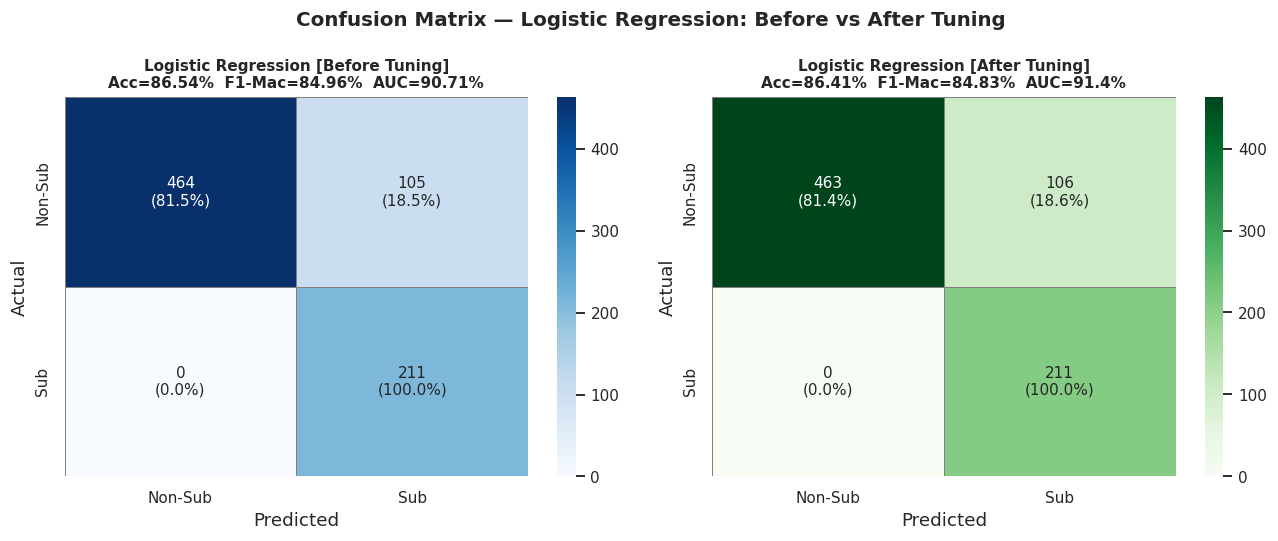

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, stage, cmap in zip(axes, ['Before Tuning','After Tuning'], ['Blues','Greens']):
    y_pred_cm = all_y_pred[BEST_BASELINE_NAME][stage]
    cm        = confusion_matrix(y_test, y_pred_cm)
    cm_pct    = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot     = np.array([[f'{v}\n({p:.1f}%)' for v,p in zip(rw,rp)]
                           for rw,rp in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, ax=ax,
                xticklabels=['Non-Sub','Sub'], yticklabels=['Non-Sub','Sub'],
                linewidths=0.5, linecolor='gray', annot_kws={'size':10})
    sub_ = df_results[(df_results['Model']==BEST_BASELINE_NAME)&(df_results['Stage']==stage)]
    ax.set_title(f'{BEST_BASELINE_NAME} [{stage}]\n'
                 f'Acc={sub_["Accuracy"].values[0]}%  '
                 f'F1-Mac={sub_["F1-Macro"].values[0]}%  '
                 f'AUC={sub_["AUC-ROC"].values[0]}%',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle(f'Confusion Matrix — {BEST_BASELINE_NAME}: Before vs After Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Classification Report — Best Model (Before & After Tuning)

In [ ]:
TARGET_NAMES = ['Non-Subscriber','Subscriber']

for stage in ['Before Tuning', 'After Tuning']:
    y_pred_cr = all_y_pred[BEST_BASELINE_NAME][stage]
    sub_ = df_results[(df_results['Model']==BEST_BASELINE_NAME)&(df_results['Stage']==stage)]
    print(f"MODEL: {BEST_BASELINE_NAME}  |  {stage.upper()}")

    print(classification_report(y_test, y_pred_cr, target_names=TARGET_NAMES))
    print(f"CV F1-Mac : {sub_['CV F1-Mac'].values[0]}% ± {sub_['CV Std'].values[0]}%"
          f" | Gen. Gap : {sub_['Gen. Gap (Test-CV)'].values[0]:+.2f}%\n")


MODEL: Logistic Regression  |  BEFORE TUNING
                precision    recall  f1-score   support

Non-Subscriber       1.00      0.82      0.90       569
    Subscriber       0.67      1.00      0.80       211

      accuracy                           0.87       780
     macro avg       0.83      0.91      0.85       780
  weighted avg       0.91      0.87      0.87       780

CV F1-Mac : 81.7% ± 1.91% | Gen. Gap : +3.21%

MODEL: Logistic Regression  |  AFTER TUNING
                precision    recall  f1-score   support

Non-Subscriber       1.00      0.81      0.90       569
    Subscriber       0.67      1.00      0.80       211

      accuracy                           0.86       780
     macro avg       0.83      0.91      0.85       780
  weighted avg       0.91      0.86      0.87       780

CV F1-Mac : 81.87% ± 1.94% | Gen. Gap : +2.98%



## 13. ROC Curve

### 13a. ROC — 4 Model Baseline  
### 13b. ROC — Best Model: Before vs After Tuning


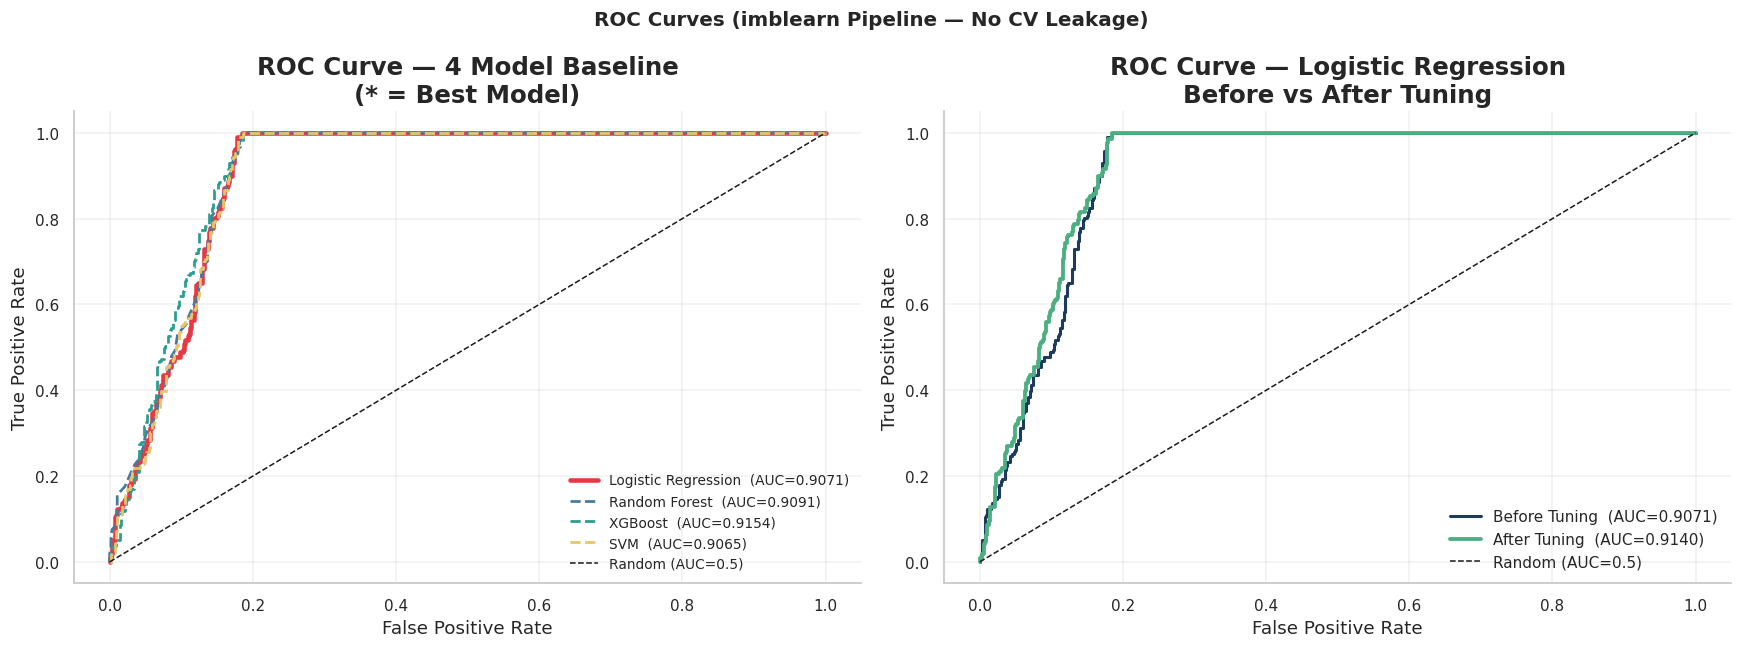

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colors_roc = ['#E63946','#457B9D','#2A9D8F','#E9C46A']
for name, color in zip(MODEL_NAMES, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, all_y_prob[name]['Before Tuning'])
    roc_val = auc(fpr, tpr)
    lw = 3 if name == BEST_BASELINE_NAME else 1.8
    ls = '-' if name == BEST_BASELINE_NAME else '--'
    ax.plot(fpr, tpr, lw=lw, color=color, linestyle=ls,
            label=f'{name}  (AUC={roc_val:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1, label='Random (AUC=0.5)')
ax.set_title('ROC Curve — 4 Model Baseline\n(* = Best Model)', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for stage, color, lw in [('Before Tuning','#1E3A5F',2), ('After Tuning','#4CAF82',2.5)]:
    fpr, tpr, _ = roc_curve(y_test, all_y_prob[BEST_BASELINE_NAME][stage])
    roc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=lw, color=color, label=f'{stage}  (AUC={roc_val:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1, label='Random (AUC=0.5)')
ax.set_title(f'ROC Curve — {BEST_BASELINE_NAME}\nBefore vs After Tuning', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('ROC Curves (imblearn Pipeline — No CV Leakage)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Feature Importance — Best Model (After Tuning)

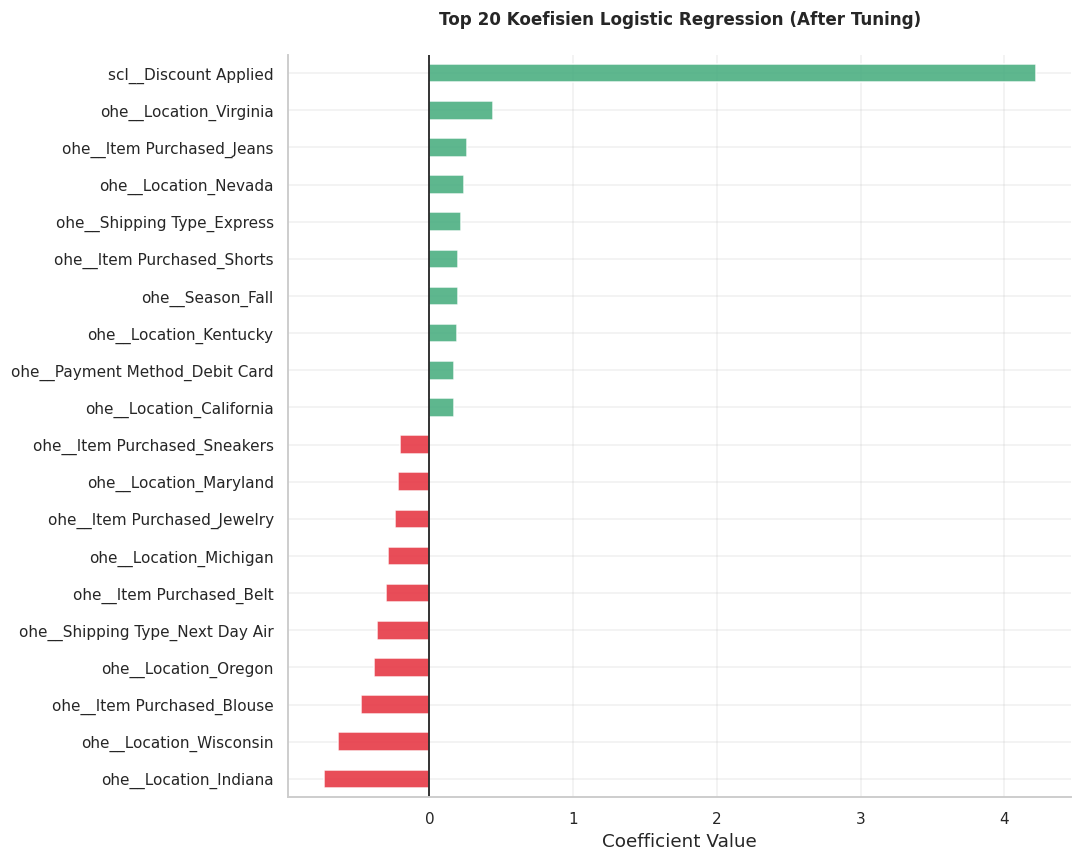

In [ ]:
model_step = fitted_pipes[BEST_BASELINE_NAME]['After Tuning'].named_steps['model']
feature_names = (
    fitted_pipes[BEST_BASELINE_NAME]['After Tuning']
    .named_steps['preprocessor']
    .get_feature_names_out()
)
coefs = pd.Series(model_step.coef_[0], index=feature_names).sort_values()

n_show = 20
coefs_show = pd.concat([coefs.head(n_show // 2), coefs.tail(n_show // 2)])

colors_coef = ['#E63946' if v < 0 else '#4CAF82' for v in coefs_show.values]
fig, ax = plt.subplots(figsize=(10, 8))
coefs_show.plot(kind='barh', ax=ax, color=colors_coef, edgecolor='white', alpha=0.9)
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'Top {n_show} Koefisien Logistic Regression (After Tuning)\n',
            fontweight='bold', fontsize=11)
ax.set_xlabel('Coefficient Value')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 15. Ringkasan Akhir & Pemilihan Model Final

In [ ]:
df_results = pd.DataFrame(all_results)

# All baseline + best tuned
df_summary = df_results.copy()
df_summary['Composite'] = (df_summary['F1-Macro'] + df_summary['AUC-ROC'] + df_summary['F1-Sub']) / 3
df_summary = df_summary.sort_values(['Stage','F1-Macro'], ascending=[True, False])


print("RINGKASAN AKHIR — Semua Model")
display(df_summary[['Model','Stage','Accuracy','F1-Macro','F1-Sub','AUC-ROC',
                     'CV F1-Mac','CV Std','Gen. Gap (Test-CV)','Composite']].reset_index(drop=True))

best_row_final = df_results[
    (df_results['Model'] == BEST_BASELINE_NAME) &
    (df_results['Stage'] == 'After Tuning')
].iloc[0]

print(f"MODEL FINAL TERPILIH : {BEST_BASELINE_NAME} (After Tuning)")

print(f"Accuracy  : {best_row_final['Accuracy']}%")
print(f"F1-Macro  : {best_row_final['F1-Macro']}%")
print(f"F1-Sub    : {best_row_final['F1-Sub']}%")
print(f"AUC-ROC   : {best_row_final['AUC-ROC']}%")
print(f"CV F1-Mac : {best_row_final['CV F1-Mac']}% ± {best_row_final['CV Std']}%")
print(f"Gen. Gap  : {best_row_final['Gen. Gap (Test-CV)']:+.2f}%")


RINGKASAN AKHIR — Semua Model


,Model,Stage,Accuracy,F1-Macro,F1-Sub,AUC-ROC,CV F1-Mac,CV Std,Gen. Gap (Test-CV),Composite
0,Logistic Regression,After Tuning,86.41,84.83,79.92,91.40,81.87,1.94,2.98,85.383333
1,Logistic Regression,Before Tuning,86.54,84.96,80.08,90.71,81.70,1.91,3.21,85.250000
2,SVM,Before Tuning,86.41,84.77,79.77,90.65,81.72,1.92,3.08,85.063333
3,Random Forest,Before Tuning,84.74,82.28,75.66,90.91,80.53,2.40,1.83,82.950000
4,XGBoost,Before Tuning,83.97,80.19,71.53,91.54,77.64,2.98,2.37,81.086667


MODEL FINAL TERPILIH : Logistic Regression (After Tuning)
Accuracy  : 86.41%
F1-Macro  : 84.83%
F1-Sub    : 79.92%
AUC-ROC   : 91.4%
CV F1-Mac : 81.87% ± 1.94%
Gen. Gap  : +2.98%


In [ ]:
import pickle

# Save the best_pipe_tuned model
filename = 'tuned_logistic_regression_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(best_pipe_tuned, file)

print(f"Tuned Logistic Regression model saved as '{filename}'")

Tuned Logistic Regression model saved as 'tuned_logistic_regression_model.pkl'


## 16. Kesimpulan

### Alur Pipeline Final

```
Raw Data (3900 baris, 19 kolom)
  ↓ Drop 4 kolom derived/leaky
  ↓ Encoding: OHE (LR/SVM) atau OrdinalEncoder (RF/XGB) — di dalam pipeline
  ↓ train_test_split(stratify=y, 80:20)
  ↓
  ┌─ Baseline (Before Tuning) ──────────────────────────────────────────────┐
  │  4 model: Logistic Regression, Random Forest, XGBoost, SVM              │
  │  Input: X_train asli → ImbPipeline → [Scaler?] → SMOTE → Model          │
  │  Evaluasi: CV 10-Fold + Test Set metrics                                │
  └─────────────────────────────────────────────────────────────────────────┘
  ↓
  ┌─ Pemilihan Model Terbaik Baseline (F1-Macro tertinggi) ─────────────────┐
  │  → Satu model dipilih → kandidat tuning                                 │
  └─────────────────────────────────────────────────────────────────────────┘
  ↓
  ┌─ Hyperparameter Tuning (After Tuning) ──────────────────────────────────┐
  │  RandomizedSearchCV(pipeline, X_train, n_iter=60, 10-Fold)              │
  │  Scoring: f1_macro | SMOTE per fold dalam pipeline                      │
  └─────────────────────────────────────────────────────────────────────────┘
  ↓
  Evaluasi Final: Confusion Matrix, Classification Report, ROC, Feature Importance
```
### Rekomendasi Bisnis
1. **Prioritaskan Recall Subscriber** — lebih baik false alarm daripada melewatkan calon subscriber
2. Fitur importance tinggi → fokus strategi retensi

